# 데이터 드라이브에서 불러오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


압축 해제

In [2]:
%cd "/content/drive/MyDrive/Colab Notebooks/AI_2_ssafy/__AI챌린지"

/content/drive/MyDrive/Colab Notebooks/AI_2_ssafy/__AI챌린지


## 시각화 환경 정리
이 셀은 EDA 그래프에서 한글이 깨지지 않도록 폰트를 설치하고 matplotlib 기본 폰트를 바꿉니다.
이후 통계 그래프를 볼 때 글자가 네모로 나오지 않는지 먼저 확인합니다.

In [3]:
# 1. 나눔 폰트 설치 (정확한 명령어)
!apt-get -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

# 2. 폰트 매니저에 나눔바른고딕 강제 등록
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe) # 폰트 리스트 맨 앞에 삽입

# 3. 전역 설정 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 나눔 폰트 설치
!apt-get -y install fonts-nanum > /dev/null

# 데이터 로드 및 구조 확인

In [ ]:
import pandas as pd

# 데이터 로드
dev_df = pd.read_csv("dev.csv")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

## 메타데이터 초안 생성
여기서는 train/dev/test CSV를 바탕으로 질문 유형과 재질 축을 붙여 `train_metadata`, `dev_metadata`, `test_metadata`를 만듭니다.
후속 분포 분석과 샘플링 실험이 모두 이 메타데이터를 기준으로 진행됩니다.

In [ ]:
import os, random
import pandas as pd

from sklearn.utils import resample

SEED =42

# ==========================================
# [신규] 질문 유형 / 재질 클래스 분류 + Train 오버샘플링
# ==========================================

def extract_task_intent(q):
    q = str(q).lower()
    if any(w in q for w in ['몇 개', '개수', '얼마나', '몇개', '몇 권']):
        return 'COUNT'
    if any(w in q for w in ['색상', '무슨 색', '색깔', '어떤 색', '색은']):
        return 'ATTRIBUTE_COLOR'
    if any(w in q for w in ['재질', '무엇으로 만들어', '만들어진', '어떤 소재', '무슨 소재']):
        return 'ATTRIBUTE_MATERIAL'
    if any(w in q for w in ['위치', '어디에', '왼쪽', '오른쪽', '위', '아래', '옆', '어느 쪽', '어느 것', '어느 그물망']):
        return 'SPATIAL_POSITION'
    if any(w in q for w in ['용량', '브랜드', '상표', '로고', '제품명', '글자', '기호', '텍스트', '쓰여진', '적혀있는', '적힌', '마크', '그림']):
        return 'TEXT_RECOGNITION'
    if any(w in q for w in ['분리수거', '재활용 분류', '분류 기호', '분리배출', '어떻게 배출', '어떻게 처리', '처리되어', '어떻게 묶']):
        return 'STATE_AND_CONDITION'
    return 'IDENTIFICATION'

def assign_material_class(row):
    text = str(row['question']) + " " + str(row.get('answer', ''))
    for kw in ['플라스틱', '유리', '종이', '알루미늄', '비닐', '금속', '스티로폼']:
        if kw in text:
            return kw
    return '기타'

for df in [train_df, dev_df, test_df]:
    df['q_type'] = df['question'].apply(extract_task_intent)

train_df['material_class'] = train_df.apply(assign_material_class, axis=1)

# ===== Train 오버샘플링 =====
print("=" * 50)
print("========== [Train] 데이터 처리 ==========")
print("=" * 50)

print(f"\n[Train] 증강 전 전체 데이터 개수: {len(train_df)}개")
print(f"[Train] 증강 전 고유 ID 개수: {train_df['id'].nunique()}개")

before_counts = train_df['material_class'].value_counts()
target_count = before_counts.max()
MAX_MULTIPLIER = 3.0

augmented_rows = []

print(f"\n=== 클래스별 증강 내역 ===")
for m_class, count in before_counts.items():
    class_df = train_df[train_df['material_class'] == m_class].copy()
    class_df['apply_aug'] = False
    augmented_rows.append(class_df)

    if m_class == '기타':
        print(f"- {m_class}: 원본 {count}개 -> 최종 {count}개")
        continue

    max_allowed = int(count * MAX_MULTIPLIER)
    final_target = min(target_count, max_allowed)
    shortfall = final_target - count

    if shortfall > 0:
        oversampled = resample(
            class_df, replace=True,
            n_samples=shortfall, random_state=SEED
        )
        oversampled['apply_aug'] = True
        augmented_rows.append(oversampled)
        print(f"- {m_class}: 원본 {count}개 -> 최종 {count + shortfall}개")
    else:
        print(f"- {m_class}: 원본 {count}개 -> 최종 {count}개")

train_metadata = pd.concat(augmented_rows).reset_index(drop=True)

print(f"\n[Train] 증강 완료 후 전체 데이터 개수: {len(train_metadata)}개")
print(f"[Train] 증강 완료 후 고유 ID 개수: {train_metadata['id'].nunique()}개 (원본과 정확히 일치해야 함)")
assert train_metadata['id'].nunique() == train_df['id'].nunique(), \
    "❌ 오류: 증강 후 고유 ID 수가 원본과 다릅니다!"
print("✅ 고유 ID 무결성 검증 통과")

n_original = int((~train_metadata['apply_aug']).sum())
n_augmented = int(train_metadata['apply_aug'].sum())
print(f"\n[Train] 원본(증강X): {n_original}개, 복제본(증강O): {n_augmented}개")

print(f"\n=== 증강 후 material_class 분포 ===")
print(train_metadata['material_class'].value_counts().to_string())

print(f"\n=== train_metadata DataFrame 구조 ===")
print(f"shape: {train_metadata.shape}")
print(f"columns: {list(train_metadata.columns)}")
print(f"dtypes:\n{train_metadata.dtypes.to_string()}")
preview = ['id', 'question', 'answer', 'material_class', 'q_type', 'apply_aug']
print(f"\n처음 3행:\n{train_metadata[[c for c in preview if c in train_metadata.columns]].head(3).to_string()}")

========== [Train] 데이터 처리 ==========

[Train] 증강 전 전체 데이터 개수: 5073개
[Train] 증강 전 고유 ID 개수: 5073개

=== 클래스별 증강 내역 ===
- 기타: 원본 2023개 -> 최종 2023개
- 플라스틱: 원본 1871개 -> 최종 2023개
- 종이: 원본 641개 -> 최종 1923개
- 유리: 원본 154개 -> 최종 462개
- 금속: 원본 151개 -> 최종 453개
- 알루미늄: 원본 133개 -> 최종 399개
- 비닐: 원본 70개 -> 최종 210개
- 스티로폼: 원본 30개 -> 최종 90개

[Train] 증강 완료 후 전체 데이터 개수: 7583개
[Train] 증강 완료 후 고유 ID 개수: 5073개 (원본과 정확히 일치해야 함)
✅ 고유 ID 무결성 검증 통과

[Train] 원본(증강X): 5073개, 복제본(증강O): 2510개

=== 증강 후 material_class 분포 ===
material_class
기타      2023
플라스틱    2023
종이      1923
유리       462
금속       453
알루미늄     399
비닐       210
스티로폼      90

=== train_metadata DataFrame 구조 ===
shape: (7583, 11)
columns: ['id', 'path', 'question', 'a', 'b', 'c', 'd', 'answer', 'q_type', 'material_class', 'apply_aug']
dtypes:
id                object
path              object
question          object
a                 object
b                 object
c                 object
d                 object
answer            object
q_type      

In [ ]:
display(test_df[test_df['q_type'] == 'COUNT'])
display(dev_metadata[dev_metadata['q_type']=='COUNT'].head())

,id,path,question,a,b,c,d,q_type,task_intent,primary_target,stratify_key
0,test_0001.jpg,test/test_0001.jpg,사진에 보이는 재활용 가능한 플라스틱 용기는 몇 개입니까?,1개,3개,4개,2개,COUNT,COUNT,플라스틱,COUNT_플라스틱
5,test_0006.jpg,test/test_0006.jpg,사진에 보이는 재활용 가능한 병 중 파란색 병은 몇 개입니까?,4개,5개,6개,3개,COUNT,COUNT,병,COUNT_병
7,test_0008.jpg,test/test_0008.jpg,사진에 보이는 재활용품 중 플라스틱 용기의 개수는 몇 개인가요?,4개,2개,1개,3개,COUNT,COUNT,플라스틱,COUNT_플라스틱
8,test_0009.jpg,test/test_0009.jpg,사진에 보이는 재활용 가능한 용기의 개수는 몇 개인가요?,3개,4개,6개,5개,COUNT,COUNT,UNKNOWN,COUNT_UNKNOWN
10,test_0011.jpg,test/test_0011.jpg,사진 속 재활용품 중 플라스틱 병은 몇 개 있나요?,2개,3개,4개,1개,COUNT,COUNT,플라스틱,COUNT_플라스틱
...,...,...,...,...,...,...,...,...,...,...,...
5064,test_5065.jpg,test/test_5065.jpg,사진에 보이는 재활용 가능한 금속 식기류는 몇 개인가요?,3개,1개,2개,4개,COUNT,COUNT,금속,COUNT_금속
5066,test_5067.jpg,test/test_5067.jpg,사진에 보이는 재활용 가능한 플라스틱 병은 몇 개입니까?,2개,없음,1개,3개,COUNT,COUNT,플라스틱,COUNT_플라스틱
5067,test_5068.jpg,test/test_5068.jpg,사진에 보이는 재활용 가능한 플라스틱 컵은 몇 개인가요?,4개,1개,3개,2개,COUNT,COUNT,플라스틱,COUNT_플라스틱
5069,test_5070.jpg,test/test_5070.jpg,사진에 보이는 재활용 가능한 플라스틱 컵은 몇 개인가요?,4개,3개,1개,2개,COUNT,COUNT,플라스틱,COUNT_플라스틱


,id,path,question,a,b,c,d,answer1,answer2,answer3,answer4,answer5,q_type,pseudo_label,agreement_rate,answer,apply_aug


## Dev 라벨 정리 실험
이 구간은 dev 데이터의 다중 응답을 pseudo-label로 바꾸고, 응답 일치율을 계산한 뒤, test 분포에 맞춘 샘플링 후보를 만듭니다.
같은 목적의 변형 셀이 연속으로 있어 필터 기준이나 비율 조정 결과를 비교하려는 흔적으로 보는 편이 맞습니다.

In [ ]:
# ==========================================
# [신규] Dev 데이터: pseudo-label + 일치율 필터링 + test 비율 샘플링
# ==========================================

print("\n" + "=" * 50)
print("========== [Valid] 데이터 처리 ==========")
print("=" * 50)

print(f"\n[Valid] 초기 Dev 전체 데이터 개수: {len(dev_df)}개")
print(f"[Valid] 초기 Dev 고유 ID 개수: {dev_df['id'].nunique()}개")

response_cols = [col for col in dev_df.columns
                 if col.startswith('answer') or col.startswith('응답')]
print(f"[Valid] 응답 컬럼: {response_cols} ({len(response_cols)}개)")

dev_responses = dev_df[response_cols]
dev_df['pseudo_label'] = dev_responses.mode(axis=1)[0]
dev_df['agreement_rate'] = dev_responses.apply(
    lambda x: (x == dev_df.loc[x.name, 'pseudo_label']).sum() / len(response_cols),
    axis=1
)

print(f"\n=== 일치율(agreement_rate) 분포 ===")
ar_dist = dev_df['agreement_rate'].value_counts().sort_index()
for rate, cnt in ar_dist.items():
    pct = cnt / len(dev_df) * 100
    print(f"  {rate:.0%} 일치: {cnt}개 ({pct:.1f}%)")


dev_df[dev_df['agreement_rate']==0.4]


========== [Valid] 데이터 처리 ==========

[Valid] 초기 Dev 전체 데이터 개수: 4413개
[Valid] 초기 Dev 고유 ID 개수: 4413개
[Valid] 응답 컬럼: ['answer1', 'answer2', 'answer3', 'answer4', 'answer5'] (5개)

=== 일치율(agreement_rate) 분포 ===
  0% 일치: 1개 (0.0%)
  20% 일치: 1개 (0.0%)
  40% 일치: 903개 (20.5%)
  60% 일치: 2606개 (59.1%)
  80% 일치: 902개 (20.4%)


,id,path,question,a,b,c,d,answer1,answer2,answer3,answer4,answer5,q_type,pseudo_label,agreement_rate
7,dev_0008.jpg,dev/dev_0008.jpg,사진 속 검은색 쓰레기봉투 안에 보이는 재활용품 중 플라스틱 병은 몇 개입니까?,1개,2개,3개,4개,b,a,a,b,c,COUNT,a,0.4
15,dev_0016.jpg,dev/dev_0016.jpg,사진 속 책상 위에 있는 재활용 가능한 플라스틱 음료 용기는 몇 개인가요?,1개,2개,3개,4개,c,a,c,a,b,COUNT,a,0.4
16,dev_0017.jpg,dev/dev_0017.jpg,사진에 보이는 재활용 가능한 플라스틱 병은 어디에 있나요?,모니터 뒤쪽에 있다.,마우스 오른쪽에 있다.,키보드 왼쪽에 있다.,마우스 패드 위에 있다.,a,a,d,b,d,SPATIAL_POSITION,a,0.4
25,dev_0026.jpg,dev/dev_0026.jpg,사진에 보이는 재활용품 중 플라스틱 용기는 어디에 있나요?,박스 안에 흰색 플라스틱 용기,갈색 종이봉투 안에 있는 플라스틱 용기,초록색 봉지 안에 있는 플라스틱 용기,투명 비닐봉지 안에 있는 플라스틱 용기,d,a,b,a,b,SPATIAL_POSITION,a,0.4
27,dev_0028.jpg,dev/dev_0028.jpg,사진에 보이는 재활용 가능한 종이 포장재는 몇 개입니까?,2개,3개,4개,5개,b,d,a,c,d,COUNT,d,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4398,dev_4399.jpg,dev/dev_4399.jpg,사진에 보이는 재활용품 중 종이 재질로 된 것은 무엇인가요?,우유 팩과 계란 판,플라스틱 컵과 초콜릿 상자,계란 판과 플라스틱 컵,초콜릿 상자와 플라스틱 컵,d,c,a,NaN,a,ATTRIBUTE_MATERIAL,a,0.4
4400,dev_4401.jpg,dev/dev_4401.jpg,사진에 보이는 재활용품 중 종이 재질로 된 것은 무엇인가요?,종이컵,플라스틱 뚜껑,종이 상자,손 세정제 용기,a,c,NaN,c,a,ATTRIBUTE_MATERIAL,a,0.4
4402,dev_4403.jpg,dev/dev_4403.jpg,사진 속 재활용품 중에서 플라스틱 재질인 것은 무엇인가요?,노니 치약 상자,커피 스크럽 튜브,과일 캔디 봉지,종이 상자,c,c,b,d,b,ATTRIBUTE_MATERIAL,b,0.4
4404,dev_4405.jpg,dev/dev_4405.jpg,사진에 보이는 재활용품 중 플라스틱 재질의 품목은 무엇인가요?,계란판,종이상자,플라스틱 컵,크림 팩,b,c,b,a,c,ATTRIBUTE_MATERIAL,b,0.4


In [ ]:
# ==========================================
# [신규] Dev 데이터: pseudo-label + 일치율 필터링 + test 비율 샘플링
# ==========================================

print("\n" + "=" * 50)
print("========== [Valid] 데이터 처리 ==========")
print("=" * 50)

print(f"\n[Valid] 초기 Dev 전체 데이터 개수: {len(dev_df)}개")
print(f"[Valid] 초기 Dev 고유 ID 개수: {dev_df['id'].nunique()}개")

response_cols = [col for col in dev_df.columns
                 if col.startswith('answer') or col.startswith('응답')]
print(f"[Valid] 응답 컬럼: {response_cols} ({len(response_cols)}개)")

dev_responses = dev_df[response_cols]
dev_df['pseudo_label'] = dev_responses.mode(axis=1)[0]
dev_df['agreement_rate'] = dev_responses.apply(
    lambda x: (x == dev_df.loc[x.name, 'pseudo_label']).sum() / len(response_cols),
    axis=1
)

print(f"\n=== 일치율(agreement_rate) 분포 ===")
ar_dist = dev_df['agreement_rate'].value_counts().sort_index()
for rate, cnt in ar_dist.items():
    pct = cnt / len(dev_df) * 100
    print(f"  {rate:.0%} 일치: {cnt}개 ({pct:.1f}%)")
AGREEMENT_THRESHOLD = 0.8

# Validation: 정답이 확실한 데이터로 평가 (기존 유지)
dev_filtered = dev_df[dev_df['agreement_rate'] >= AGREEMENT_THRESHOLD].copy()

# Train: 모호한 데이터도 학습에 포함 (추가)
# dev에서 agreement 0.6인 데이터를 train에 추가
ambiguous_dev = dev_df[(dev_df['agreement_rate'] <= 0.6)].copy()

print(f"\n[추가] 모호한 Dev 데이터 (일치율 60%): {len(ambiguous_dev)}개를 Train에 추가")

train_metadata = pd.concat([train_metadata, ambiguous_dev]).reset_index(drop=True)

print(f"[Train] 최종 데이터 개수: {len(train_metadata)}개")

print(f"\n[Valid 추적 1] 일치율 {AGREEMENT_THRESHOLD:.0%} 이상 필터링 후 남은 데이터 개수: "
      f"{len(dev_filtered)}개 (노이즈 제거로 인한 감소)")
print(f"  필터링으로 제거된 데이터: {len(dev_df) - len(dev_filtered)}개")

test_type_ratios = test_df['q_type'].value_counts(normalize=True)
total_dev_samples = int(len(dev_filtered) * 0.8)

print(f"\n=== Test 질문 유형 비율 (샘플링 목표) ===")
for qtype, ratio in test_type_ratios.items():
    target_n = max(1, int(total_dev_samples * ratio))
    available_n = len(dev_filtered[dev_filtered['q_type'] == qtype])
    status = "✅" if available_n >= target_n else "⚠️ 부족→복원추출"
    print(f"  {qtype:25s}: 비율 {ratio:.1%}, 목표 {target_n}개, 가용 {available_n}개 {status}")

ddev_sampled_list = []
for q_type, ratio in test_type_ratios.items():
    type_data = dev_filtered[dev_filtered['q_type'] == q_type]
    if len(type_data) > 0:
        dev_sampled_list.append(type_data)  # 있는 그대로 전부 사용

dev_metadata = pd.concat(dev_sampled_list).reset_index(drop=True)
dev_metadata['answer'] = dev_metadata['pseudo_label']
dev_metadata['apply_aug'] = False

print(f"\n[Valid 추적 2] Test 비율 반영 샘플링 완료 후 전체 Valid 데이터 개수: {len(dev_metadata)}개")
print(f"[Valid 추적 2] Test 비율 반영 샘플링 완료 후 고유 ID 개수: {dev_metadata['id'].nunique()}개")
print("*(참고: Test 분포를 맞추기 위해 특정 유형을 다운/업샘플링하면서 고유 ID가 변동하는 것은 정상입니다)*")

print(f"\n=== Valid 데이터 질문 유형(q_type) 분포 (Test 비율 반영) ===")
print(dev_metadata['q_type'].value_counts(normalize=True).mul(100).round(2).to_string())

print(f"\n[Valid] 최종 일치율 평균: {dev_metadata['agreement_rate'].mean():.2f}")
print(f"[Valid] 최종 일치율 최소: {dev_metadata['agreement_rate'].min():.2f}")

print(f"\n=== dev_metadata DataFrame 구조 ===")
print(f"shape: {dev_metadata.shape}")
print(f"columns: {list(dev_metadata.columns)}")
preview_dev = ['id', 'question', 'answer', 'pseudo_label', 'agreement_rate', 'q_type', 'apply_aug']
print(f"\n처음 3행:\n{dev_metadata[[c for c in preview_dev if c in dev_metadata.columns]].head(3).to_string()}")


========== [Valid] 데이터 처리 ==========

[Valid] 초기 Dev 전체 데이터 개수: 4413개
[Valid] 초기 Dev 고유 ID 개수: 4413개
[Valid] 응답 컬럼: ['answer1', 'answer2', 'answer3', 'answer4', 'answer5'] (5개)

=== 일치율(agreement_rate) 분포 ===
  0% 일치: 1개 (0.0%)
  20% 일치: 1개 (0.0%)
  40% 일치: 903개 (20.5%)
  60% 일치: 2606개 (59.1%)
  80% 일치: 902개 (20.4%)

[추가] 모호한 Dev 데이터 (일치율 40~60%): 3509개를 Train에 추가
[Train] 최종 데이터 개수: 15504개

[Valid 추적 1] 일치율 60% 이상 필터링 후 남은 데이터 개수: 902개 (노이즈 제거로 인한 감소)
  필터링으로 제거된 데이터: 3511개

=== Test 질문 유형 비율 (샘플링 목표) ===
  COUNT                    : 비율 33.8%, 목표 243개, 가용 715개 ✅
  ATTRIBUTE_MATERIAL       : 비율 30.4%, 목표 219개, 가용 79개 ⚠️ 부족→복원추출
  IDENTIFICATION           : 비율 19.8%, 목표 143개, 가용 48개 ⚠️ 부족→복원추출
  ATTRIBUTE_COLOR          : 비율 6.4%, 목표 46개, 가용 21개 ⚠️ 부족→복원추출
  SPATIAL_POSITION         : 비율 4.7%, 목표 33개, 가용 28개 ⚠️ 부족→복원추출
  STATE_AND_CONDITION      : 비율 3.9%, 목표 27개, 가용 7개 ⚠️ 부족→복원추출
  TEXT_RECOGNITION         : 비율 0.9%, 목표 6개, 가용 4개 ⚠️ 부족→복원추출

[Valid 추적 2] Test 비율 반영 샘플링 완료 후 전체 Valid 데이

## 랜덤 샘플 점검
이 셀은 각 split에서 질문/선지/정답이 어떻게 들어있는지 몇 개만 뽑아 눈으로 확인하는 용도입니다.
형식이 깨진 행이나 예상과 다른 질문 유형이 있는지 빠르게 점검할 때 사용합니다.

In [ ]:
# 기본 구조 확인
# 랜덤 추출
def inspect_data(df, name, n=5):
    print(f"{'='*20} [{name} Random Sample] {'='*20}")
    sample_size = min(n, len(df))
    display(df.sample(n=sample_size))
    print(f"Total Rows: {len(df)}\n")

inspect_data(train_df, "train.csv")
inspect_data(dev_df, "dev.csv")
inspect_data(test_df, "test.csv")

==================== [train.csv Random Sample] ====================


,id,path,question,a,b,c,d,answer
4845,train_4846.jpg,train/train_4846.jpg,사진 속 재활용 쓰레기 중 캔 음료는 몇 개입니까?,11개,7개,13개,9개,c
1465,train_1466.jpg,train/train_1466.jpg,사진에 보이는 재활용 가능한 플라스틱 컵은 몇 개인가요?,1개,3개,4개,2개,d
4917,train_4918.jpg,train/train_4918.jpg,사진에 보이는 재활용 용기의 재질은 무엇인가요?,유리 재질 용기,종이 재질 용기,플라스틱 재질 용기,금속 재질 용기,c
3451,train_3452.jpg,train/train_3452.jpg,사진에 보이는 재활용 가능한 봉지의 개수는 몇 개인가요?,3개,2개,4개,1개,b
270,train_0271.jpg,train/train_0271.jpg,사진에 보이는 음료 용기의 재질은 무엇인가요?,금속,유리,종이,플라스틱,d


Total Rows: 5073

==================== [dev.csv Random Sample] ====================


,id,path,question,a,b,c,d,answer1,answer2,answer3,answer4,answer5
626,dev_0627.jpg,dev/dev_0627.jpg,사진에 보이는 재활용품 중 종이 상자는 몇 개입니까?,3개,4개,5개,6개,c,c,b,c,b
1273,dev_1274.jpg,dev/dev_1274.jpg,사진 속 재활용 쓰레기봉투 안에 보이는 플라스틱 컵은 몇 개입니까?,1개,2개,3개,4개,c,c,b,a,a
3150,dev_3151.jpg,dev/dev_3151.jpg,사진에 보이는 재활용품 중 종이 재질의 상자는 몇 개입니까?,1개,2개,3개,4개,b,b,b,a,c
4398,dev_4399.jpg,dev/dev_4399.jpg,사진에 보이는 재활용품 중 종이 재질로 된 것은 무엇인가요?,우유 팩과 계란 판,플라스틱 컵과 초콜릿 상자,계란 판과 플라스틱 컵,초콜릿 상자와 플라스틱 컵,d,c,a,NaN,a
1285,dev_1286.jpg,dev/dev_1286.jpg,사진에 보이는 재활용 가능한 플라스틱 포장지는 몇 개입니까?,1개,2개,3개,4개,d,b,c,d,d


Total Rows: 4413

==================== [test.csv Random Sample] ====================


,id,path,question,a,b,c,d
4051,test_4052.jpg,test/test_4052.jpg,책상 위에 있는 재활용 가능한 플라스틱 병의 개수는 몇 개인가요?,2개,3개,4개,1개
2735,test_2736.jpg,test/test_2736.jpg,사진에 보이는 재활용품 중 플라스틱 재질인 것은 무엇인가요?,비닐봉지,플라스틱 컵과 빨대,페트병 음료수,종이컵 홀더
1566,test_1567.jpg,test/test_1567.jpg,사진에 보이는 재활용 가능한 플라스틱 포장지의 개수는 몇 개인가요?,3개,5개,2개,4개
3385,test_3386.jpg,test/test_3386.jpg,사진에 보이는 두 개의 재활용품 중 종이 재질의 포장재는 몇 개인가요?,3개,4개,2개,1개
622,test_0623.jpg,test/test_0623.jpg,사진에 보이는 재활용품 중 종이 재질의 포장지는 무엇인가요?,감자칩 비닐봉지,플라스틱 병,유리병,누룽지 스낵 박스


Total Rows: 5074



## 이미지와 질문을 같이 보는 확인용 뷰어
표 통계만으로는 놓치기 쉬운 케이스를 직접 보기 위해 이미지, 질문, 선지, 정답을 함께 띄우는 셀입니다.
질문 유형 분류나 전처리 방향이 맞는지 감으로 확인하는 단계에 가깝습니다.

In [ ]:
# 이미지와 함께 확인

from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets
from io import BytesIO

def inspect_vqa_compact(df, name, n=3, st=None):
    print(f"{'='*20} [{name} - Random Sample] {'='*20} \n")
    display(HTML("<style>.v-card{width:380px;border:1px solid #ddd;border-radius:12px;overflow:hidden;background:#fff;box-shadow:0 2px 5px #0001;}.q-box{background:#e7f1ff;padding:12px;font-weight:bold;color:#0d6efd;border-bottom:1px solid #cfe2ff;font-size:14px;}.m-row{display:flex;padding:5px 12px;font-size:13px;border-bottom:1px solid #f8f9fa;}.m-key{font-weight:bold;min-width:90px;color:#666;}.m-val{word-break:break-all;white-space:normal;}</style>"))

    items = []
    if st is not None:
        samples = df.iloc[st : st + n].iterrows()
    else: samples = df.sample(min(n, len(df))).iterrows()
    for idx, row in samples:
        try:
            img = Image.open(str(row['path']))
            w, h = img.size
            img.thumbnail((360, 360))
            buf = BytesIO(); img.save(buf, format='PNG')
            img_w, sz_info = widgets.Image(value=buf.getvalue(), width=360), f"{w} x {h}"
        except:
            img_w, sz_info = widgets.HTML("Image Not Found"), "0 x 0"

        meta = "".join([f"<div class='m-row'><span class='m-key'>{c}</span><span class='m-val'>{v}</span></div>"
                        for c, v in zip(df.columns[3:], row.iloc[3:])])

        html = f"""<div class='v-card'>
            <div style='text-align:center;font-size:11px;color:#999;padding:5px'>Size: {sz_info} | {row.iloc[0]}</div>
            <div class='q-box'>
                <small style='color:#666;font-weight:normal;font-size:10px;'>[{df.columns[2]}]</small><br>{row.iloc[2]}
            </div>
            <div style='padding:5px 0'>{meta}</div>
        </div>"""
        items.append(widgets.VBox([img_w, widgets.HTML(html)], layout=widgets.Layout(margin='0 10px')))

    display(widgets.HBox(items, layout=widgets.Layout(flex_flow='row wrap', justify_content='space-around', width='100%')))
    print(f"[{name}] Total Rows: {len(df)} \n\n")


# -----------------------------------------
# inspect_vqa_compact(train_df, "TRAIN", n=4)
# inspect_vqa_compact(dev_df[(dev_df['q_type'] == 'COUNT') & (dev_df['agreement_rate'] == 0.4)], "DEV", n=10)
inspect_vqa_compact(test_df[test_df['q_type'] == 'COUNT'], "TEST", n=100)

==================== [TEST - Random Sample] ==================== 



[TEST] Total Rows: 1717 




# 통계 확인

In [ ]:
import os
from tqdm.auto import tqdm

def check_missing_files(df, name, path_col='path'):
    # tqdm을 사용해 진행 상황 시각화 (데이터가 많을 때 유용)
    missing = [p for p in tqdm(df[path_col].tolist(), desc=f"Checking {name}") if not os.path.exists(p)]

    print(f"\n[ {name} 결측 파일 보고서 ]")
    print(f"- 확인된 총 이미지 수: {len(df)}")
    print(f"- 누락된 파일 수: {len(missing)}")

    if missing:
        print(f"⚠️ 누락된 파일 예시 (최대 5개): {missing[:5]}")
    else:
        print("✅ 모든 이미지 파일이 경로에 정상적으로 존재합니다.")
    return missing

# 세 데이터셋 모두 확인
train_missing = check_missing_files(train_df, "TRAIN")
dev_missing = check_missing_files(dev_df, "DEV")
test_missing = check_missing_files(test_df, "TEST")

Checking TRAIN:   0%|          | 0/5073 [00:00<?, ?it/s]


[ TRAIN 결측 파일 보고서 ]
- 확인된 총 이미지 수: 5073
- 누락된 파일 수: 0
✅ 모든 이미지 파일이 경로에 정상적으로 존재합니다.


Checking DEV:   0%|          | 0/4413 [00:00<?, ?it/s]


[ DEV 결측 파일 보고서 ]
- 확인된 총 이미지 수: 4413
- 누락된 파일 수: 0
✅ 모든 이미지 파일이 경로에 정상적으로 존재합니다.


Checking TEST:   0%|          | 0/5074 [00:00<?, ?it/s]


[ TEST 결측 파일 보고서 ]
- 확인된 총 이미지 수: 5074
- 누락된 파일 수: 0
✅ 모든 이미지 파일이 경로에 정상적으로 존재합니다.


## 전체 split 요약 통계
train/dev/test 크기, 컬럼, 질문 유형, 응답 합의도 같은 전반 지표를 한 번에 훑는 함수입니다.
이 단계에서 데이터셋 간 성격 차이가 큰지 먼저 확인합니다.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

def comprehensive_eda(train_df, dev_df, test_df):
    dfs = {'train': train_df, 'dev': dev_df, 'test': test_df}

    # 1. 컬럼 구성 및 결측치 요약
    print("### [1] 데이터셋 구성 및 결측치 요약")
    summary_list = []
    for name, df in dfs.items():
        summary_list.append(df.isna().sum().to_frame(f'{name}_na'))
    display(pd.concat(summary_list, axis=1).fillna('-'))

    # 2. 고유값 및 중복 검사 (id, path 기준)
    print("\n### [2] 중복 데이터 및 고유성 검사")
    dup_stats = []
    for name, df in dfs.items():
        dup_stats.append({
            'Dataset': name,
            'Total Rows': len(df),
            'Unique ID': df['id'].nunique(),
            'Dup ID': df['id'].duplicated().sum(),
            'Unique Path': df['path'].nunique(),
            'Dup Path': df['path'].duplicated().sum()
        })
    display(pd.DataFrame(dup_stats))

    # 3. 데이터셋 간 유출(Leakage) 검사 (핵심)
    print("\n### [3] 데이터셋 간 이미지 경로(path) 중복 여부 (Data Leakage)")
    train_paths = set(train_df['path'])
    dev_paths = set(dev_df['path'])
    test_paths = set(test_df['path'])

    leakage_stats = {
        'Train ∩ Dev': len(train_paths & dev_paths),
        'Train ∩ Test': len(train_paths & test_paths),
        'Dev ∩ Test': len(dev_paths & test_paths)
    }
    print(leakage_stats)

    # 4. dev 데이터 응답 일치도(Consensus) 분석 (가장 중요)
    print("\n### [4] dev 데이터 응답 일치도 분석")
    # 응답 컬럼 자동 탐색 (answer1, answer2... 또는 응답1, 응답2...)
    ans_cols = [c for c in dev_df.columns if 'answer' in c or '응답' in c]

    if ans_cols:
        # 각 행별로 가장 많이 나온 응답의 빈도 계산
        def get_consensus_ratio(row):
            responses = row[ans_cols].dropna()
            if len(responses) == 0: return 0
            return responses.value_counts().iloc[0] / len(responses)

        dev_df['consensus_ratio'] = dev_df.apply(get_consensus_ratio, axis=1)

        print(f"- 평균 응답 일치도: {dev_df['consensus_ratio'].mean():.2%}")
        print("- 완전 불일치 문항(비율 <= 0.4) 개수:", len(dev_df[dev_df['consensus_ratio'] <= 0.4]))
        print("- 완전 일치 문항(비율 == 1.0) 개수:", len(dev_df[dev_df['consensus_ratio'] == 1.0]))
    else:
        print("dev 데이터에 응답 컬럼이 존재하지 않습니다.")

# 실행
comprehensive_eda(train_df, dev_df, test_df)

### [1] 데이터셋 구성 및 결측치 요약


,train_na,dev_na,test_na
id,0.0,0.0,0.0
path,0.0,0.0,0.0
question,0.0,0.0,0.0
a,0.0,0.0,0.0
b,0.0,0.0,0.0
c,0.0,0.0,0.0
d,0.0,0.0,0.0
answer,1.0,-,-
answer1,-,2.0,-
answer2,-,19.0,-



### [2] 중복 데이터 및 고유성 검사


,Dataset,Total Rows,Unique ID,Dup ID,Unique Path,Dup Path
0,train,5073,5073,0,5073,0
1,dev,4413,4413,0,4413,0
2,test,5074,5074,0,5074,0



### [3] 데이터셋 간 이미지 경로(path) 중복 여부 (Data Leakage)
{'Train ∩ Dev': 0, 'Train ∩ Test': 0, 'Dev ∩ Test': 0}

### [4] dev 데이터 응답 일치도 분석
- 평균 응답 일치도: 60.34%
- 완전 불일치 문항(비율 <= 0.4) 개수: 873
- 완전 일치 문항(비율 == 1.0) 개수: 13


## 정답 분포 확인
정답 a/b/c/d 비율을 확인해 특정 선택지가 과도하게 많거나 적은지 봅니다.
학습 시 class imbalance가 심하면 분할이나 샘플링 전략에 영향을 줍니다.

,개수,비율(%)
answer,,
a,1263,24.901420
b,1265,24.940852
c,1311,25.847792
d,1233,24.309937


/tmp/ipykernel_10744/3973463989.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


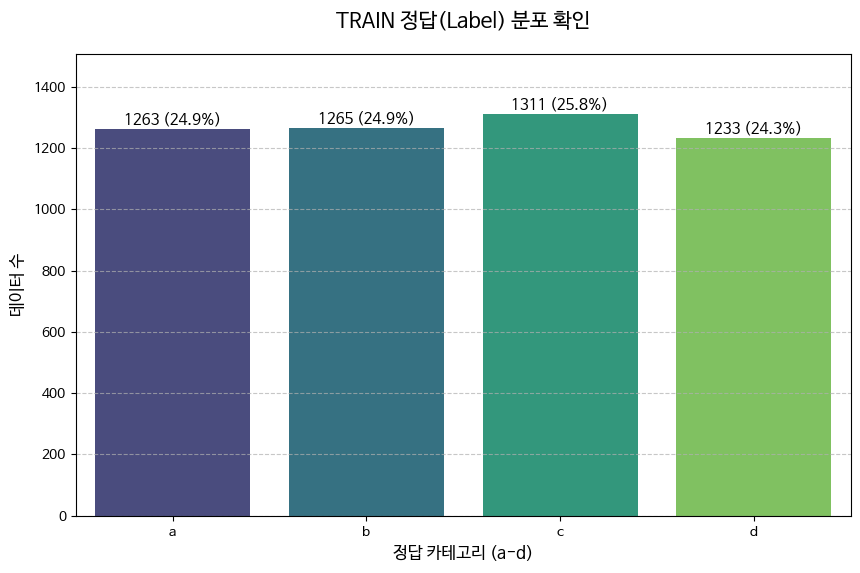

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_answer_distribution(df, name="Train"):
    # 1. 데이터 집계
    counts = df['answer'].value_counts().sort_index()
    perc = df['answer'].value_counts(normalize=True).sort_index() * 100
    stats = pd.concat([counts, perc], axis=1, keys=['개수', '비율(%)'])

    display(stats)

    # 2. 시각화
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')

    # 상단에 수치 표시 (개수 및 비율)
    for i, p in enumerate(ax.patches):
        ax.annotate(f'{int(p.get_height())} ({perc.iloc[i]:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                    textcoords='offset points')

    plt.title(f'{name} 정답(Label) 분포 확인', fontsize=15, pad=20)
    plt.xlabel('정답 카테고리 (a-d)', fontsize=12)
    plt.ylabel('데이터 수', fontsize=12)
    plt.ylim(0, counts.max() * 1.15) # 라벨 공간 확보
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 실행
plot_answer_distribution(train_df, "TRAIN")

## Dev 다중 응답 일치도 분석
이 셀은 dev의 여러 응답 열을 이용해 질문별 합의 강도를 계산합니다.
후속 pseudo-label 생성에서 어느 정도까지 신뢰할지 정하는 근거로 쓰입니다.

/tmp/ipykernel_10744/210646048.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[0])


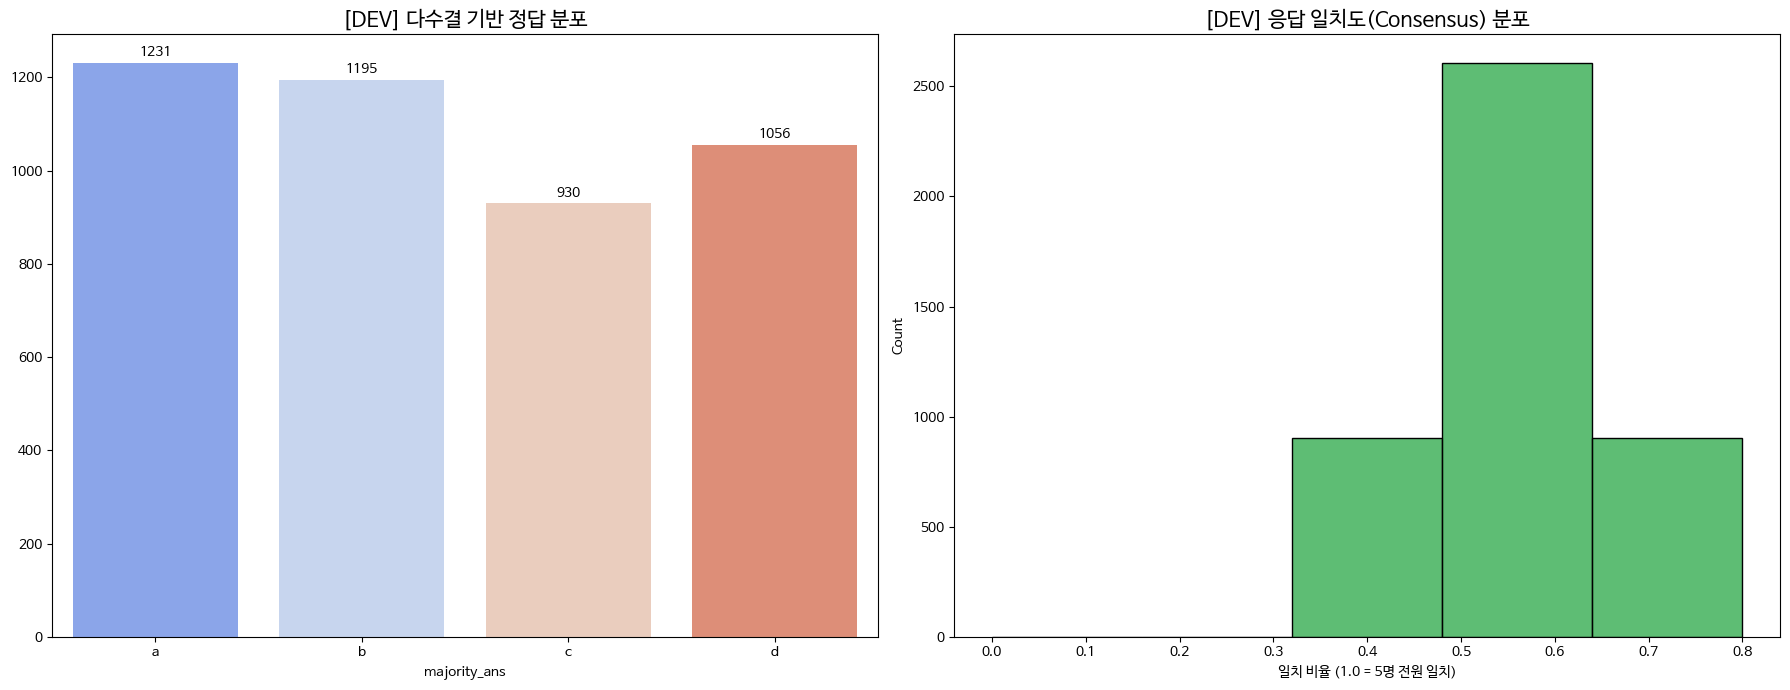


[ DEV 데이터 요약 ]
- 평균 응답 일치도: 59.97%
- 5명 전원 일치 문항: 0 개
- 과반수 미만 일치(0.4 이하) 문항: 905 개


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dev_distribution(df, name="DEV"):
    # 1. 응답 컬럼 추출 (answer1~5 또는 응답1~5)
    ans_cols = [c for c in df.columns if 'answer' in c or '응답' in c]
    if not ans_cols:
        print("❌ 응답 컬럼을 찾을 수 없습니다.")
        return

    # 2. 행별 최빈값(Majority Vote) 및 일치도 계산
    # 최빈값이 여러 개일 경우 첫 번째 값을 선택
    df['majority_ans'] = df[ans_cols].mode(axis=1)[0]

    # 일치도 계산: (최빈값의 개수 / 전체 응답 수)
    def calculate_agreement(row):
        counts = row[ans_cols].value_counts()
        return counts.max() / len(ans_cols) if not counts.empty else 0

    df['agreement_rate'] = df.apply(calculate_agreement, axis=1)

    # 3. 시각화 (2개 서브플롯)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # [Left] 다수결 정답 분포
    counts = df['majority_ans'].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[0])
    axes[0].set_title(f'[{name}] 다수결 기반 정답 분포', fontsize=15)
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                         ha='center', va='center', xytext=(0, 7), textcoords='offset points')

    # [Right] 응답 일치도 분포 (신뢰도 확인)
    sns.histplot(df['agreement_rate'], bins=5, kde=False, color='#28a745', ax=axes[1])
    axes[1].set_title(f'[{name}] 응답 일치도(Consensus) 분포', fontsize=15)
    axes[1].set_xlabel('일치 비율 (1.0 = 5명 전원 일치)')

    plt.tight_layout()
    plt.show()

    # 요약 보고서
    print(f"\n[ {name} 데이터 요약 ]")
    print(f"- 평균 응답 일치도: {df['agreement_rate'].mean():.2%}")
    print(f"- 5명 전원 일치 문항: {len(df[df['agreement_rate'] == 1.0])} 개")
    print(f"- 과반수 미만 일치(0.4 이하) 문항: {len(df[df['agreement_rate'] <= 0.4])} 개")

# 실행
analyze_dev_distribution(dev_df)

## 이미지 해상도와 비율 확인
원본 이미지의 가로·세로 분포와 비율을 확인해 리사이즈/패딩 전처리 필요성을 판단합니다.
크롭이나 패딩 전략이 필요한지 보는 셀입니다.

📊 이미지 해상도 분석 중 (샘플 1000개)...


  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_10744/4020280622.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df.head(10), x='빈도', y='해상도', ax=ax[0], palette='coolwarm')


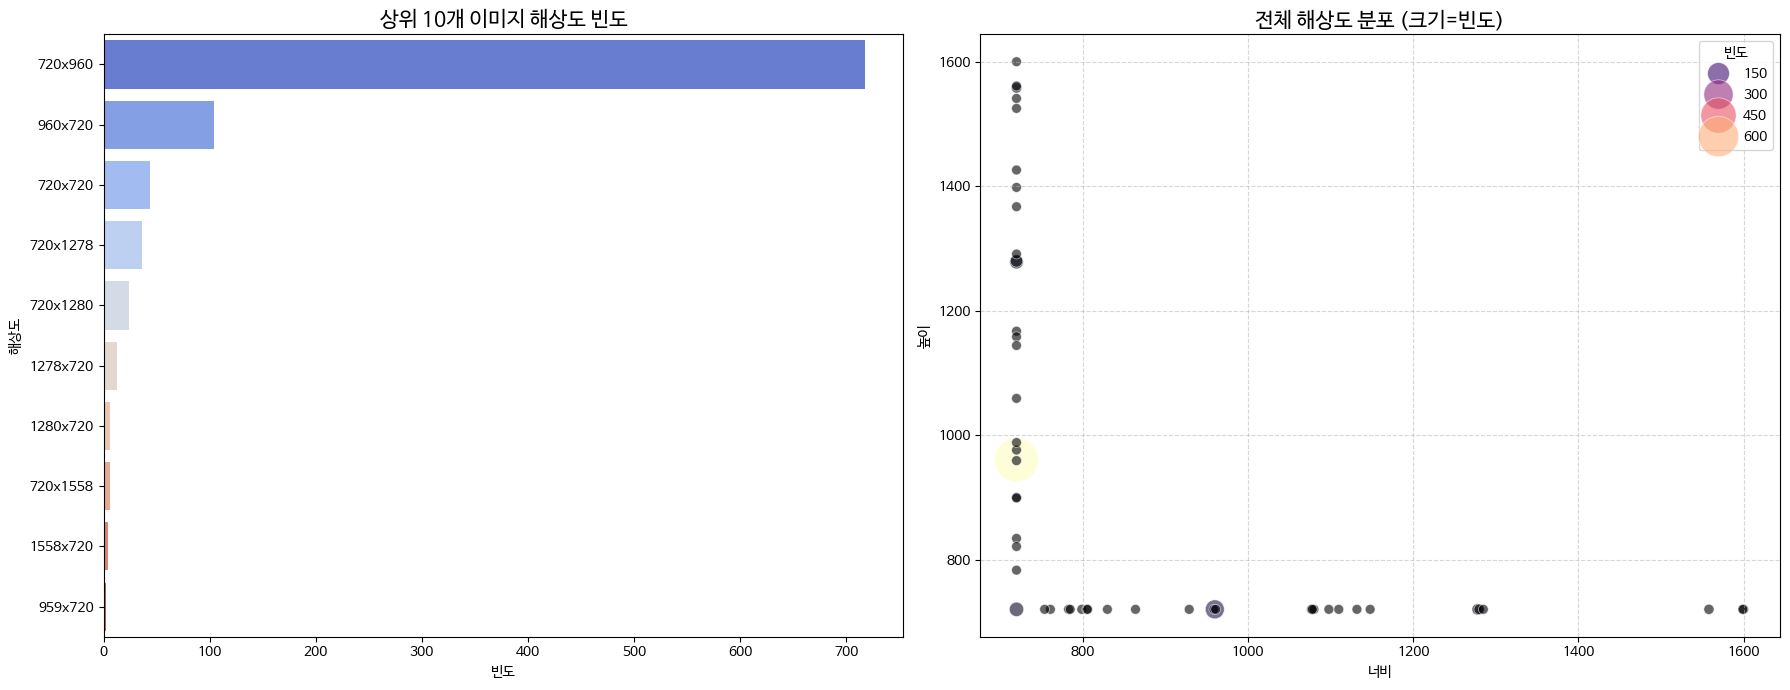


[ 해상도 상위 7개 ]


,해상도,너비,높이,빈도
1,720x960,720,960,718
5,960x720,960,720,104
0,720x720,720,720,44
6,720x1278,720,1278,36
3,720x1280,720,1280,24
16,1278x720,1278,720,13
2,1280x720,1280,720,6


In [ ]:
import os, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm

def draw_resolution_chart(df, n=1000):
    print(f"📊 이미지 해상도 분석 중 (샘플 {n}개)...")
    res = []
    for p in tqdm(df['path'].sample(min(n, len(df)))):
        if os.path.exists(p):
            with Image.open(p) as img: res.append(img.size)

    # 데이터 가공
    counts = Counter(res)
    res_df = pd.DataFrame([{'해상도': f"{w}x{h}", '너비': w, '높이': h, '빈도': c}
                           for (w, h), c in counts.items()]).sort_values('빈도', ascending=False)

    # 차트 그리기
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))

    # (좌) 상위 10개 빈도 해상도
    sns.barplot(data=res_df.head(10), x='빈도', y='해상도', ax=ax[0], palette='coolwarm')
    ax[0].set_title('상위 10개 이미지 해상도 빈도', fontsize=15)

    # (우) 해상도 분포 (너비 vs 높이)
    sns.scatterplot(data=res_df, x='너비', y='높이', size='빈도', hue='빈도',
                    sizes=(50, 1000), alpha=0.6, ax=ax[1], palette='magma')
    ax[1].set_title('전체 해상도 분포 (크기=빈도)', fontsize=15)
    ax[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print("\n[ 해상도 상위 7개 ]")
    display(res_df.head(7))

# 실행
draw_resolution_chart(train_df)

## 질문/선지 길이 분석
질문과 보기 텍스트 길이를 비교해 프롬프트 길이, 잘림 위험, 질문 유형별 차이를 확인합니다.
프롬프트 구성과 max length 설정에 참고할 수 있습니다.

,mean,50%,max
[Train] len_question,31.806623,31.0,73.0
[Train] len_a,4.423812,3.0,42.0
[Train] len_b,4.420067,3.0,34.0
[Train] len_c,4.394638,3.0,33.0
[Train] len_d,4.456140,3.0,40.0
[Dev] len_question,32.966689,32.0,71.0
[Dev] len_a,3.731022,2.0,43.0
[Dev] len_b,3.614548,2.0,43.0
[Dev] len_c,3.459325,2.0,43.0
[Dev] len_d,3.381600,2.0,43.0


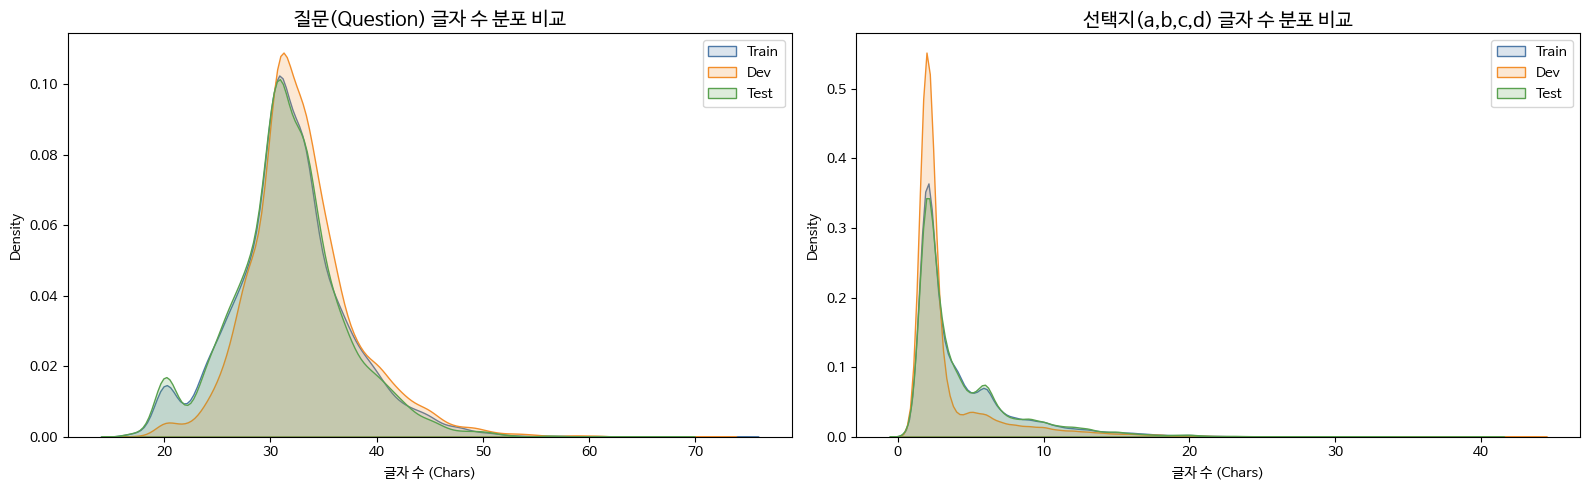

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_text_lengths(dfs, split_names):
    # 1. 길이 계산 및 통합 데이터 생성
    all_stats = []
    cols_to_check = ['question', 'a', 'b', 'c', 'd']

    for df, name in zip(dfs, split_names):
        temp_df = df.copy()
        for col in cols_to_check:
            # 결측치 대비를 위해 문자열 변환 후 길이 계산
            temp_df[f'len_{col}'] = temp_df[col].astype(str).apply(len)

        # 통계 요약 (Mean, Max 위주)
        summary = temp_df[[f'len_{c}' for c in cols_to_check]].describe().T[['mean', '50%', 'max']]
        summary.index = [f"[{name}] {idx}" for idx in summary.index]
        all_stats.append(summary)

    # 요약 표 출력
    display(pd.concat(all_stats))

    # 2. 시각화 (질문 vs 선택지 분포 비교)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#4e79a7', '#f28e2b', '#59a14f'] # Train, Dev, Test 색상

    for i, (df, name) in enumerate(zip(dfs, split_names)):
        # 질문 길이 분포
        sns.kdeplot(df['question'].astype(str).apply(len), ax=axes[0], label=name, color=colors[i], fill=True, alpha=0.2)

        # 선택지(a,b,c,d 합산) 길이 분포
        opt_lens = pd.concat([df[c].astype(str).apply(len) for c in ['a', 'b', 'c', 'd']])
        sns.kdeplot(opt_lens, ax=axes[1], label=name, color=colors[i], fill=True, alpha=0.2)

    axes[0].set_title('질문(Question) 글자 수 분포 비교', fontsize=14)
    axes[0].set_xlabel('글자 수 (Chars)')
    axes[0].legend()

    axes[1].set_title('선택지(a,b,c,d) 글자 수 분포 비교', fontsize=14)
    axes[1].set_xlabel('글자 수 (Chars)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 실행
analyze_text_lengths([train_df, dev_df, test_df], ['Train', 'Dev', 'Test'])

## 이미지 파일 스펙 점검
파일 존재 여부, 크기, 모드(RGB 등) 같은 이미지 속성을 모아 봅니다.
훈련 전에 깨진 파일이나 예외 케이스를 찾는 목적도 있습니다.

🔍 [TRAIN] 이미지 메타데이터 추출 중...


TRAIN:   0%|          | 0/5073 [00:00<?, ?it/s]


[ TRAIN 이미지 규격 요약 ]


,mean,std,min,50%,max
width,765.918786,127.698283,720.000000,720.00,1600.000000
height,943.668047,153.136997,720.000000,960.00,1636.000000
aspect_ratio,0.845769,0.272294,0.440098,0.75,2.222222


이미지 모드 분포: {'RGB': 5073}


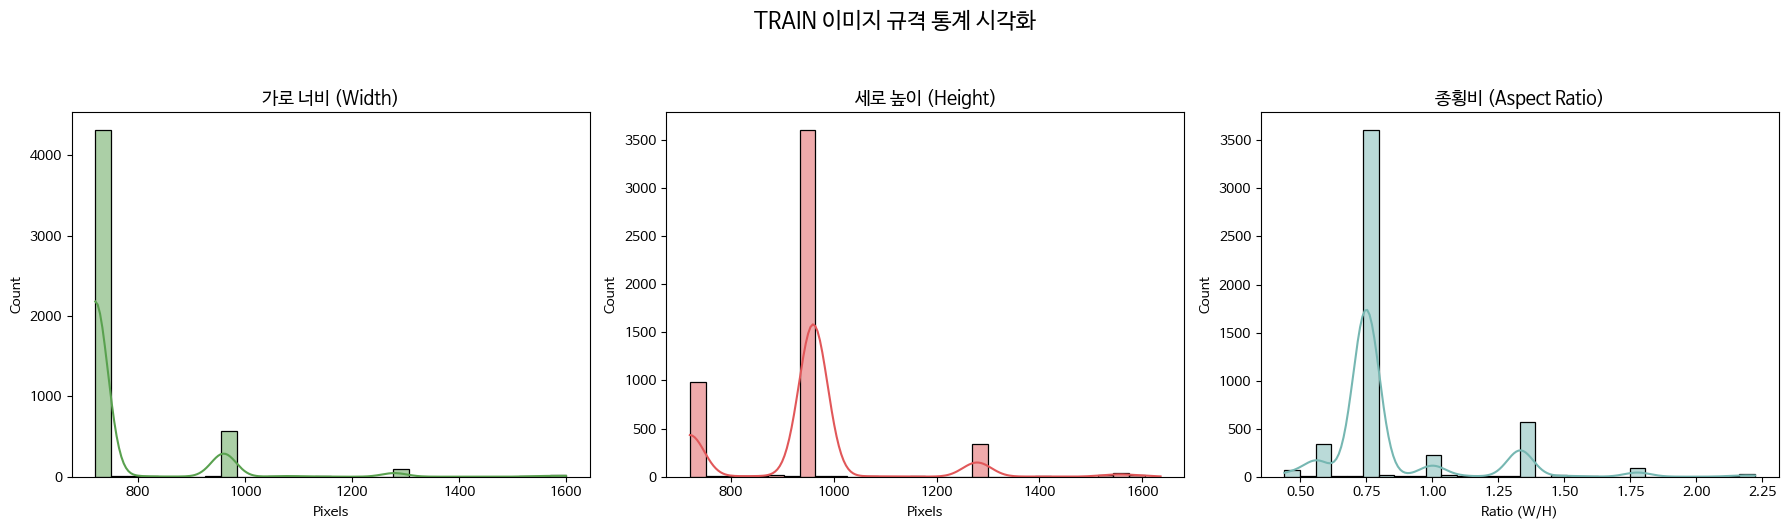

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

def analyze_image_specs(df, name="Dataset"):
    print(f"🔍 [{name}] 이미지 메타데이터 추출 중...")

    meta_data = []
    # tqdm을 사용하여 진행 상황 모니터링
    for path in tqdm(df['path'], desc=name):
        try:
            with Image.open(path) as img:
                w, h = img.size
                meta_data.append({
                    'width': w,
                    'height': h,
                    'mode': img.mode,
                    'aspect_ratio': w / h
                })
        except Exception as e:
            # 파일 손상이나 경로 오류 대비
            meta_data.append({'width': None, 'height': None, 'mode': None, 'aspect_ratio': None})

    meta_df = pd.DataFrame(meta_data)

    # 1. 기술 통계량 출력
    print(f"\n[ {name} 이미지 규격 요약 ]")
    display(meta_df[['width', 'height', 'aspect_ratio']].describe().T[['mean', 'std', 'min', '50%', 'max']])

    # 2. 이미지 모드(RGB, RGBA 등) 확인
    mode_counts = meta_df['mode'].value_counts().to_dict()
    print(f"이미지 모드 분포: {mode_counts}")

    # 3. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#59a14f', '#e15759', '#76b7b2']
    titles = ['가로 너비 (Width)', '세로 높이 (Height)', '종횡비 (Aspect Ratio)']
    cols = ['width', 'height', 'aspect_ratio']

    for i, col in enumerate(cols):
        sns.histplot(meta_df[col].dropna(), bins=30, kde=True, ax=axes[i], color=colors[i])
        axes[i].set_title(titles[i], fontsize=13)
        axes[i].set_xlabel('Pixels' if i < 2 else 'Ratio (W/H)')

    plt.suptitle(f"{name} 이미지 규격 통계 시각화", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

    return meta_df

# 실행 (Train 세트 기준)
train_meta = analyze_image_specs(train_df, "TRAIN")

## Stratified split 실험
정답 분포를 유지하면서 train/valid를 나누는 분할 함수를 시험합니다.
단순 랜덤 분할보다 분포 보존이 필요한지 확인하는 단계입니다.

In [ ]:
import pandas as pd
import numpy as np

def stratified_split_refined(df, label_col='answer', train_ratio=0.9, seed=42):
    # 1. 데이터 정제 (결측치 제거)
    initial_count = len(df)
    df_cleaned = df.dropna(subset=[label_col]).copy()
    dropped_count = initial_count - len(df_cleaned)

    if dropped_count > 0:
        print(f"⚠️ [Data Cleaning] '{label_col}' 결측치 {dropped_count}개를 제거했습니다. (남은 데이터: {len(df_cleaned)}개)")

    # 2. 계층 분할 로직
    # 전체 셔플
    shuffled = df_cleaned.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # 그룹 내 순번 및 그룹별 총 개수 계산
    group_counts = shuffled.groupby(label_col).cumcount()
    group_sizes = shuffled.groupby(label_col)[label_col].transform('count')

    # 분할 임계치 계산 (IntCastingNaNError 방지를 위해 np.floor 사용)
    train_threshold = (group_sizes * train_ratio).apply(np.floor).astype(int)
    train_mask = group_counts < train_threshold

    # 데이터 분할
    train_out = shuffled[train_mask].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    valid_out = shuffled[~train_mask].sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return train_out, valid_out

# [실행 및 결과 출력]
train_split_df, valid_split_df = stratified_split_refined(train_df, label_col='answer', train_ratio=0.9, seed=42)

# --- 결과 시각화 및 검증 ---
print("\n" + "="*50)
print(f"📊 데이터 분할 결과 요약 (Ratio: 9:1)")
print("="*50)
print(f"Total Train : {train_split_df.shape[0]} rows")
print(f"Total Valid : {valid_split_df.shape[0]} rows")
print("-" * 50)

# 정답 비율 비교 테이블 생성
train_ratio = train_split_df['answer'].value_counts(normalize=True).sort_index() * 100
valid_ratio = valid_split_df['answer'].value_counts(normalize=True).sort_index() * 100

comparison_df = pd.DataFrame({
    'Train 개수': train_split_df['answer'].value_counts().sort_index(),
    'Train 비율(%)': train_ratio.round(2),
    'Valid 개수': valid_split_df['answer'].value_counts().sort_index(),
    'Valid 비율(%)': valid_ratio.round(2),
    '차이(Diff)': (train_ratio - valid_ratio).abs().round(4)
})

display(comparison_df)
print("="*50)

⚠️ [Data Cleaning] 'answer' 결측치 1개를 제거했습니다. (남은 데이터: 5072개)

📊 데이터 분할 결과 요약 (Ratio: 9:1)
Total Train : 4562 rows
Total Valid : 510 rows
--------------------------------------------------


,Train 개수,Train 비율(%),Valid 개수,Valid 비율(%),차이(Diff)
answer,,,,,
a,1136,24.90,127,24.90,0.0006
b,1138,24.95,127,24.90,0.0432
c,1179,25.84,132,25.88,0.0384
d,1109,24.31,124,24.31,0.0042


## 고급 진단: 질문 유형·보기 품질·어휘 특성
이 구간은 질문을 count/material/general 축으로 다시 태깅하고, 보기 길이·어휘 다양성·정답 위치 같은 편향 신호를 확인합니다.
모델이 내용 이해보다 데이터 습관을 학습할 위험이 있는지 보는 분석입니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

def run_advanced_diagnostics(train_df, test_df):
    print("="*50)
    print("🚀 VQA 데이터 품질 및 편향(Bias) 정밀 진단 시작")
    print("="*50)

    # 1) 질문 유형 태깅 (규칙 기반)
    QUESTION_PATTERNS = {
        'color': r'색|색깔',
        'count': r'몇|개수|몇 개|마리|명',
        'location': r'어디|장소|위치',
        'object': r'무엇|어떤 것|어떤 물건',
        'action': r'무슨|행동|하고 있',
        'time_weather': r'날씨|계절|시간|밤|낮',
    }

    def tag_question(q: str) -> str:
        q = str(q)
        for tag, pat in QUESTION_PATTERNS.items():
            if re.search(pat, q): return tag
        return 'other'

    train_diag, test_diag = train_df.copy(), test_df.copy()
    train_diag['q_tag'] = train_diag['question'].apply(tag_question)
    test_diag['q_tag'] = test_diag['question'].apply(tag_question)

    print('\n### [1] 질문 유형 분포 비교 (Train vs Test)')
    tag_dist = pd.DataFrame({
        'Train Count': train_diag['q_tag'].value_counts(),
        'Test Count': test_diag['q_tag'].value_counts()
    }).fillna(0).astype(int)
    display(tag_dist)

    print('\n### [2] 질문 유형별 정답(a,b,c,d) 쏠림 현상 (%)')
    tag_answer = pd.crosstab(train_diag['q_tag'], train_diag['answer'], normalize='index') * 100
    display(tag_answer.round(2))

    # 2) 보기 품질 진단 (중복, 길이 편차, 어휘 겹침)
    def normalize_text(x: str) -> str:
        return re.sub(r'\s+', ' ', str(x).strip().lower())

    def option_quality(row):
        opts = [normalize_text(row[c]) for c in ['a', 'b', 'c', 'd']]
        unique_n = len(set(opts))
        lengths = [len(o) for o in opts]

        # Jaccard 유사도 계산
        token_sets = [set(o.split()) for o in opts]
        overlaps = []
        for i in range(4):
            for j in range(i+1, 4):
                uni = len(token_sets[i] | token_sets[j])
                if uni == 0: overlaps.append(1.0)
                else: overlaps.append(len(token_sets[i] & token_sets[j]) / uni)

        return pd.Series({
            'has_dup_option': unique_n < 4,
            'len_gap': max(lengths) - min(lengths),
            'mean_jaccard': np.mean(overlaps)
        })

    print('\n### [3] 선택지(Option) 품질 진단')
    quality_df = train_diag.apply(option_quality, axis=1)
    diag_df = pd.concat([train_diag, quality_df], axis=1)

    print(f"- 보기 중복이 있는 질문 비율: {diag_df['has_dup_option'].mean() * 100:.2f}%")
    display(diag_df[['len_gap', 'mean_jaccard']].describe().T[['mean', 'std', 'max']])

    # 3) 정답 위치 및 길이 편향 점검
    for c in ['a', 'b', 'c', 'd']:
        diag_df[f'len_{c}'] = diag_df[c].astype(str).str.len()

    def answer_len_rank(row):
        if pd.isna(row['answer']): return np.nan
        lens = {c: row[f'len_{c}'] for c in ['a', 'b', 'c', 'd']}
        # 길이가 짧은 순으로 랭크 매기기 (1=가장 짧음, 4=가장 김)
        sorted_items = sorted(lens.items(), key=lambda x: x[1])
        ranks = {k: i+1 for i, (k, _) in enumerate(sorted_items)}
        return ranks.get(row['answer'], np.nan)

    diag_df['answer_len_rank'] = diag_df.apply(answer_len_rank, axis=1)
    print('\n### [4] 정답 길이 편향 (1: 가장 짧은 보기 ~ 4: 가장 긴 보기)')
    display(diag_df['answer_len_rank'].value_counts(normalize=True).sort_index().mul(100).round(2).to_frame('선택 확률(%)'))

    # 4) Train-Test 어휘 커버리지 (OOV)
    def build_vocab(df, cols):
        vocab = set()
        for col in cols:
            for txt in df[col].dropna().astype(str).tolist():
                vocab.update(re.findall(r'[가-힣a-zA-Z0-9]+', txt.lower()))
        return vocab

    train_vocab = build_vocab(train_diag, ['question', 'a', 'b', 'c', 'd'])
    test_vocab = build_vocab(test_diag, ['question', 'a', 'b', 'c', 'd'])

    inter = len(train_vocab & test_vocab)
    union = len(train_vocab | test_vocab)
    test_oov_ratio = (len(test_vocab - train_vocab) / len(test_vocab) * 100) if len(test_vocab) else 0.0

    print('\n### [5] Train-Test 데이터 분포 교차 검증')
    print(f"- 어휘 겹침 유사도 (Jaccard): {inter / union if union else 0:.4f}")
    print(f"- Test 기준 미등록 단어(OOV) 비율: {test_oov_ratio:.2f}%\n")

    # 자동 요약 힌트
    print("💡 [모델링 액션 플랜 자동 도출]")
    if diag_df['has_dup_option'].mean() > 0.01:
        print("🚨 [경고] 중복 보기가 존재합니다. 모델이 혼란을 겪을 수 있으니 전처리로 제거하십시오.")
    if diag_df['answer_len_rank'].value_counts(normalize=True).max() > 0.35:
        print("🚨 [경고] 모델이 이미지를 보지 않고 '가장 짧은/긴 보기'를 찍는 꼼수를 부릴 위험이 큽니다. (Language Prior 발생)")
    if test_oov_ratio > 10:
        print("🚨 [경고] Test 셋에 처음 보는 단어가 많습니다. 강한 텍스트 증강 기법이나 외부 사전학습 모델(RoBERTa 등) 적용이 필수입니다.")
    else:
        print("✅ 어휘 분포가 안정적입니다. 모델의 시각적 특징(Visual Feature) 추출 성능을 높이는 데 집중하십시오.")

# 실행
run_advanced_diagnostics(train_df, test_df)

🚀 VQA 데이터 품질 및 편향(Bias) 정밀 진단 시작

### [1] 질문 유형 분포 비교 (Train vs Test)


,Train Count,Test Count
q_tag,,
object,2382,2409
count,1801,1792
color,473,450
other,300,306
location,117,117



### [2] 질문 유형별 정답(a,b,c,d) 쏠림 현상 (%)


answer,a,b,c,d
q_tag,,,,
color,22.62,25.16,28.33,23.89
count,24.82,25.60,25.60,23.99
location,23.93,28.21,23.93,23.93
object,25.62,24.23,25.45,24.70
other,23.67,25.00,27.33,24.00



### [3] 선택지(Option) 품질 진단
- 보기 중복이 있는 질문 비율: 0.02%


,mean,std,max
len_gap,2.515868,2.945783,25.0
mean_jaccard,0.032276,0.095803,1.0



### [4] 정답 길이 편향 (1: 가장 짧은 보기 ~ 4: 가장 긴 보기)


,선택 확률(%)
answer_len_rank,
1.0,16.94
2.0,18.85
3.0,22.14
4.0,42.07



### [5] Train-Test 데이터 분포 교차 검증
- 어휘 겹침 유사도 (Jaccard): 0.4324
- Test 기준 미등록 단어(OOV) 비율: 40.78%

💡 [모델링 액션 플랜 자동 도출]
🚨 [경고] 모델이 이미지를 보지 않고 '가장 짧은/긴 보기'를 찍는 꼼수를 부릴 위험이 큽니다. (Language Prior 발생)
🚨 [경고] Test 셋에 처음 보는 단어가 많습니다. 강한 텍스트 증강 기법이나 외부 사전학습 모델(RoBERTa 등) 적용이 필수입니다.


📊 VQA 데이터 편향 및 품질 시각화 대시보드 생성 중...



/tmp/ipykernel_10744/809816639.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rank_dist.index, y=rank_dist.values, palette='mako', ax=ax4)


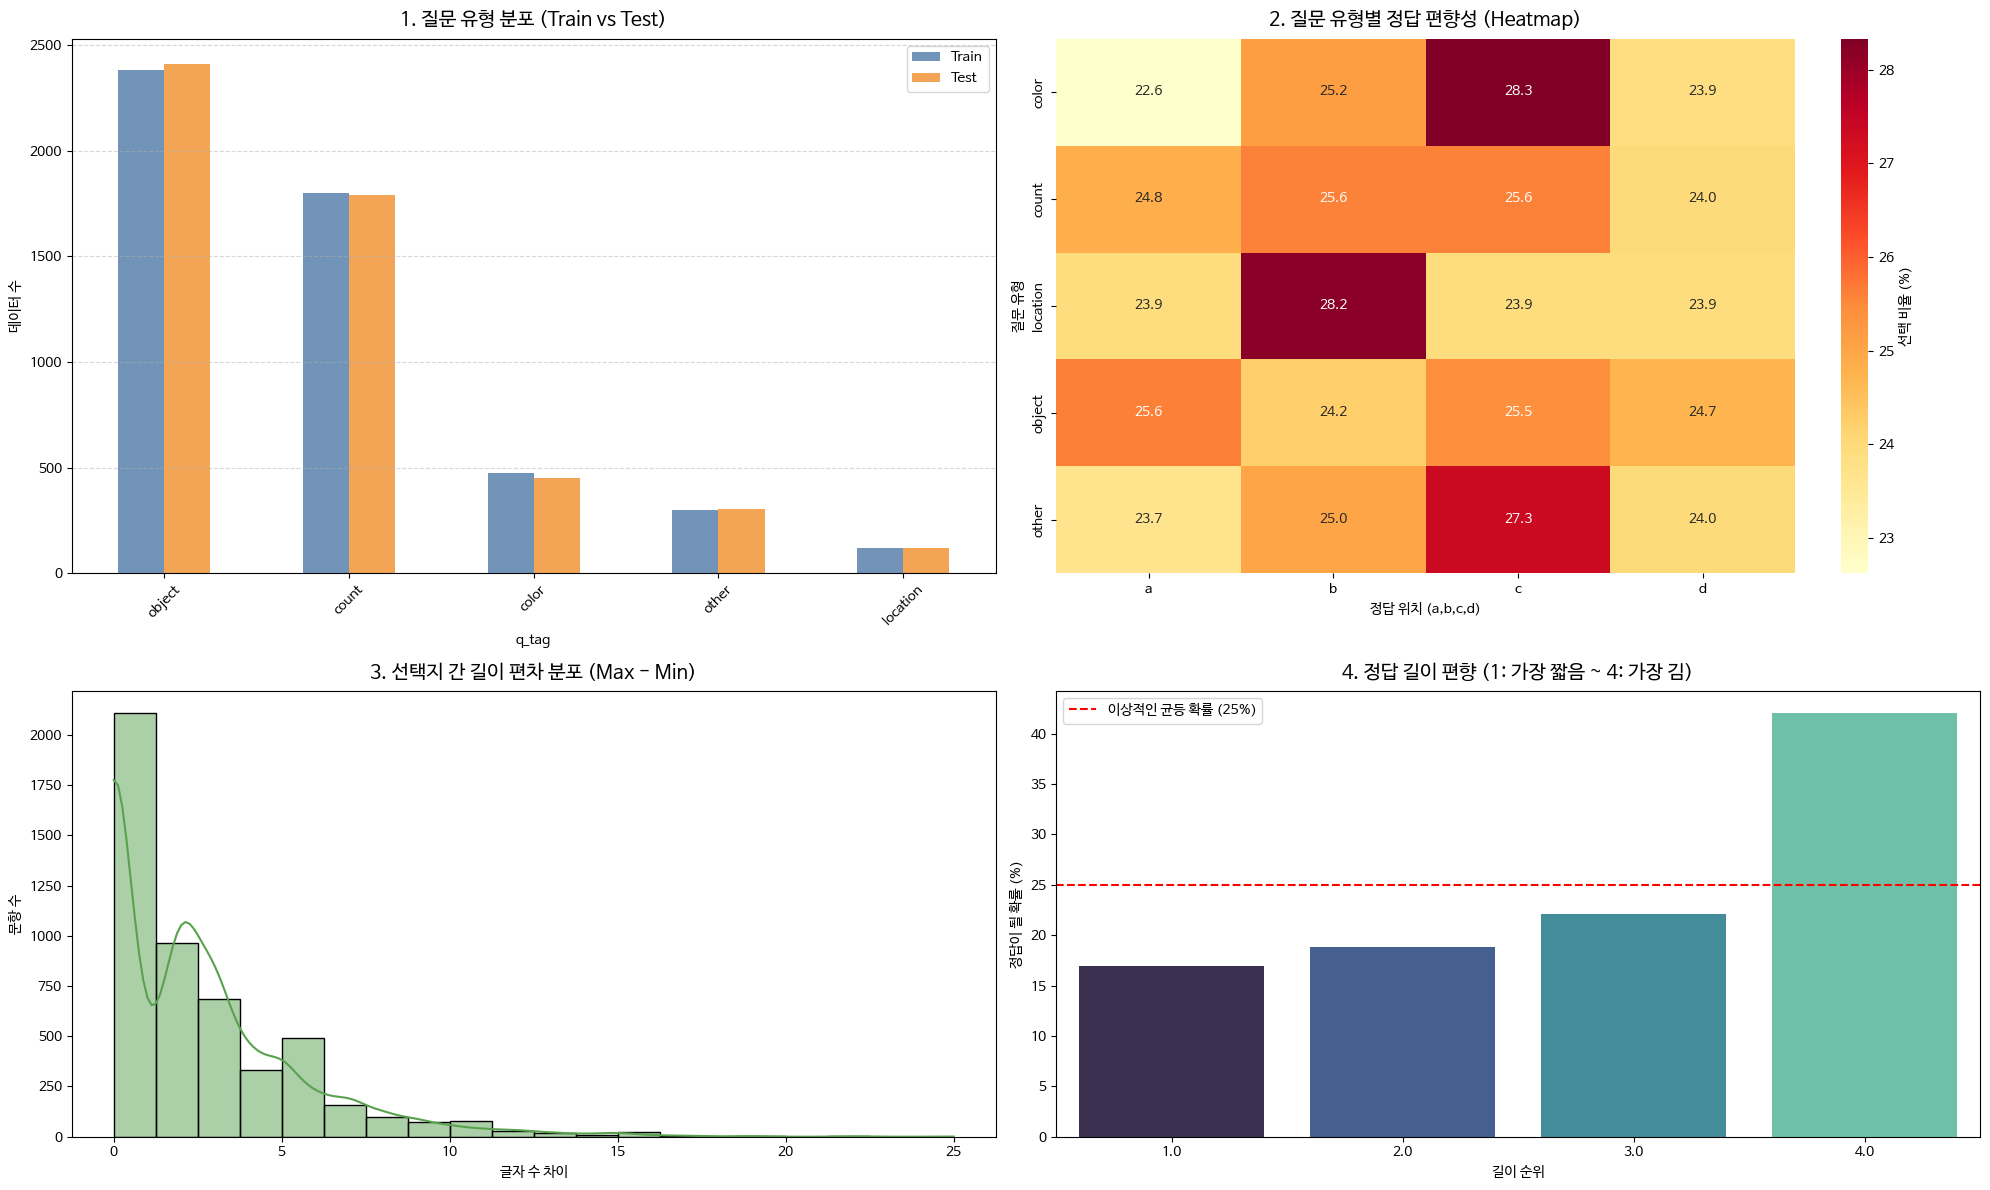

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 한글 폰트 강제 설정 (코랩 환경 기준)
import matplotlib.font_manager as fm
!apt-get -y install fonts-nanum > /dev/null
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

def visualize_advanced_diagnostics(train_df, test_df):
    print("📊 VQA 데이터 편향 및 품질 시각화 대시보드 생성 중...\n")

    # --- 데이터 전처리 (태깅 및 길이 계산) ---
    QUESTION_PATTERNS = {
        'color': r'색|색깔', 'count': r'몇|개수|몇 개|마리|명', 'location': r'어디|장소|위치',
        'object': r'무엇|어떤 것|어떤 물건', 'action': r'무슨|행동|하고 있', 'time_weather': r'날씨|계절|시간|밤|낮'
    }
    def tag_question(q):
        for tag, pat in QUESTION_PATTERNS.items():
            if re.search(pat, str(q)): return tag
        return 'other'

    train_diag, test_diag = train_df.copy(), test_df.copy()
    train_diag['q_tag'] = train_diag['question'].apply(tag_question)
    test_diag['q_tag'] = test_diag['question'].apply(tag_question)

    def get_quality_metrics(row):
        opts = [re.sub(r'\s+', ' ', str(row[c]).strip().lower()) for c in ['a', 'b', 'c', 'd']]
        lens = [len(o) for o in opts]

        # 정답 길이 랭크
        if pd.isna(row['answer']): rank = np.nan
        else:
            sorted_lens = sorted({c: len(str(row[c])) for c in ['a', 'b', 'c', 'd']}.items(), key=lambda x: x[1])
            rank = {k: i+1 for i, (k, _) in enumerate(sorted_lens)}.get(row['answer'], np.nan)

        return pd.Series({'len_gap': max(lens) - min(lens), 'answer_len_rank': rank})

    quality_df = train_diag.apply(get_quality_metrics, axis=1)
    diag_df = pd.concat([train_diag, quality_df], axis=1)

    # --- 시각화 레이아웃 설정 ---
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

    # 1. 질문 유형 분포 (Train vs Test)
    ax1 = fig.add_subplot(gs[0, 0])
    tag_dist = pd.DataFrame({'Train': train_diag['q_tag'].value_counts(), 'Test': test_diag['q_tag'].value_counts()}).fillna(0)
    tag_dist.plot(kind='bar', ax=ax1, color=['#4e79a7', '#f28e2b'], alpha=0.8)
    ax1.set_title('1. 질문 유형 분포 (Train vs Test)', fontsize=14, pad=10)
    ax1.set_ylabel('데이터 수')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # 2. 질문 유형별 정답(a,b,c,d) 쏠림 현상 (Heatmap)
    ax2 = fig.add_subplot(gs[0, 1])
    tag_answer = pd.crosstab(train_diag['q_tag'], train_diag['answer'], normalize='index') * 100
    sns.heatmap(tag_answer, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax2, cbar_kws={'label': '선택 비율 (%)'})
    ax2.set_title('2. 질문 유형별 정답 편향성 (Heatmap)', fontsize=14, pad=10)
    ax2.set_ylabel('질문 유형')
    ax2.set_xlabel('정답 위치 (a,b,c,d)')

    # 3. 보기 길이 편차 (Length Gap)
    ax3 = fig.add_subplot(gs[1, 0])
    sns.histplot(diag_df['len_gap'], bins=20, kde=True, color='#59a14f', ax=ax3)
    ax3.set_title('3. 선택지 간 길이 편차 분포 (Max - Min)', fontsize=14, pad=10)
    ax3.set_xlabel('글자 수 차이')
    ax3.set_ylabel('문항 수')

    # 4. 정답 위치 편향 (가장 짧은 보기 vs 가장 긴 보기)
    ax4 = fig.add_subplot(gs[1, 1])
    rank_dist = diag_df['answer_len_rank'].value_counts(normalize=True).sort_index() * 100
    sns.barplot(x=rank_dist.index, y=rank_dist.values, palette='mako', ax=ax4)
    ax4.set_title('4. 정답 길이 편향 (1: 가장 짧음 ~ 4: 가장 김)', fontsize=14, pad=10)
    ax4.set_xlabel('길이 순위')
    ax4.set_ylabel('정답이 될 확률 (%)')
    ax4.axhline(25, color='red', linestyle='--', label='이상적인 균등 확률 (25%)')
    ax4.legend()

    plt.tight_layout()
    plt.show()

# 실행
visualize_advanced_diagnostics(train_df, test_df)

## 질문 유형별 품질 비교
질문 유형마다 보기 구성이나 정답 패턴이 다른지 따로 비교합니다.
한 모델로 모두 처리할지, counting 같은 유형을 별도 전략으로 분리할지 판단하는 데 도움을 줍니다.

데이터 전처리 및 메트릭 계산 중 (종속성 없이 독립 실행)...
질문 유형별 선택지 품질 심층 분석 시작


,Count,Gap_Mean,Gap_Std,Jac_Mean,Jac_Std
Type,,,,,
color,473,1.218,1.753,0.034,0.103
count,1801,0.268,1.169,0.015,0.085
location,117,4.863,3.104,0.206,0.134
object,2382,4.280,2.825,0.033,0.085
other,300,3.137,2.528,0.060,0.131


/tmp/ipykernel_10744/2471760464.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diag_df, x='q_tag', y='len_gap', ax=axes[0], palette='pastel')
/tmp/ipykernel_10744/2471760464.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diag_df, x='q_tag', y='mean_option_jaccard', ax=axes[1], palette='pastel')


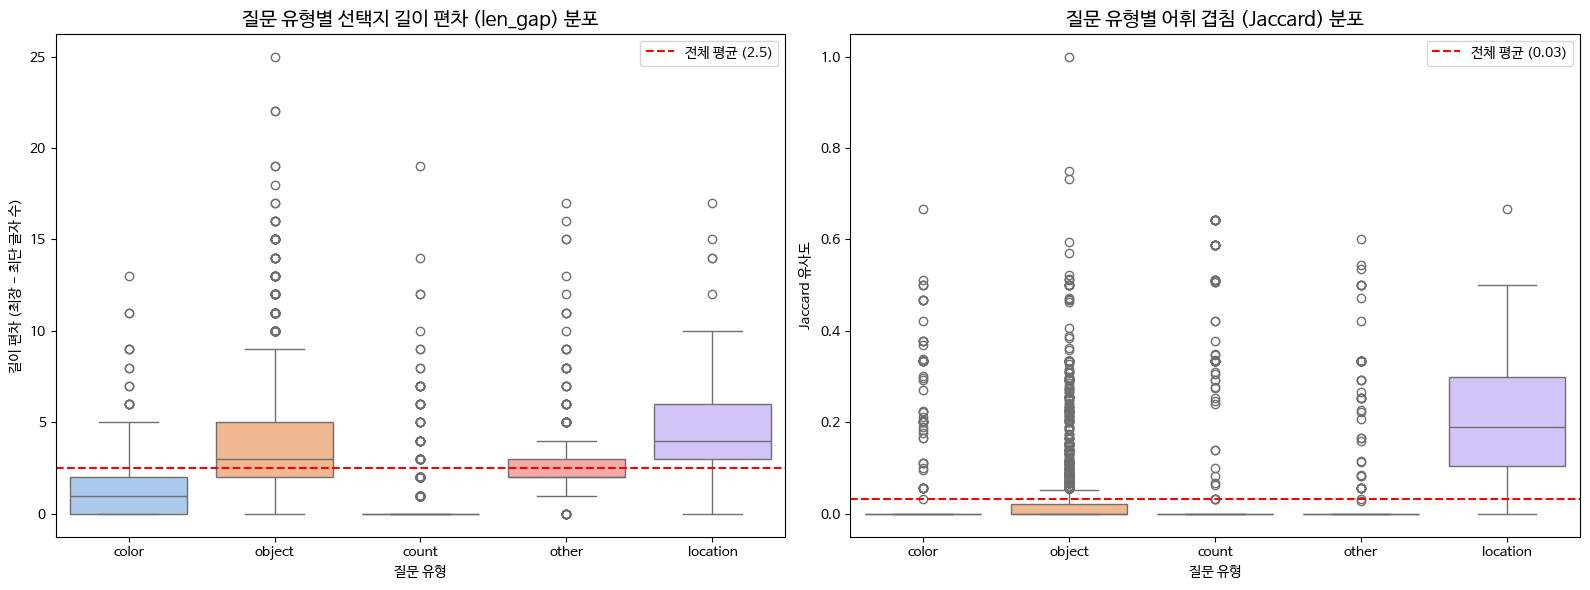


[ 'count' (개수 세기) 유형 심화 진단 ] (n=1801)
- Jaccard 상위 10% 임계값: 0.0000
- Jaccard 0.3 이상 비율: 2.9%
정상: 개수 세기 문제의 보기 길이가 비교적 균일합니다.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

def analyze_quality_by_qtype_standalone(df):
    print("=" * 80)
    print("데이터 전처리 및 메트릭 계산 중 (종속성 없이 독립 실행)...")

    # 1. 내부 전처리 로직 (태깅 및 메트릭 계산)
    QUESTION_PATTERNS = {
        'color': r'색|색깔', 'count': r'몇|개수|몇 개|마리|명', 'location': r'어디|장소|위치',
        'object': r'무엇|어떤 것|어떤 물건', 'action': r'무슨|행동|하고 있', 'time_weather': r'날씨|계절|시간|밤|낮'
    }

    def tag_question(q):
        for tag, pat in QUESTION_PATTERNS.items():
            if re.search(pat, str(q)): return tag
        return 'other'

    def get_metrics(row):
        opts = [re.sub(r'\s+', ' ', str(row[c]).strip().lower()) for c in ['a', 'b', 'c', 'd']]
        lens = [len(o) for o in opts]

        token_sets = [set(o.split()) for o in opts]
        overlaps = []
        for i in range(4):
            for j in range(i+1, 4):
                uni = len(token_sets[i] | token_sets[j])
                if uni == 0: overlaps.append(1.0)
                else: overlaps.append(len(token_sets[i] & token_sets[j]) / uni)

        return pd.Series({
            'q_tag': tag_question(row['question']),
            'len_gap': max(lens) - min(lens),
            'mean_option_jaccard': np.mean(overlaps)
        })

    # 원본 데이터에 메트릭 결합
    diag_df = pd.concat([df.copy(), df.apply(get_metrics, axis=1)], axis=1)

    print("질문 유형별 선택지 품질 심층 분석 시작")
    print("=" * 80)

    # 2. 통계 요약표 생성
    stats_list = []
    for q_type in sorted(diag_df['q_tag'].unique()):
        sub = diag_df[diag_df['q_tag'] == q_type]
        stats_list.append({
            'Type': q_type,
            'Count': len(sub),
            'Gap_Mean': sub['len_gap'].mean(),
            'Gap_Std': sub['len_gap'].std(),
            'Jac_Mean': sub['mean_option_jaccard'].mean(),
            'Jac_Std': sub['mean_option_jaccard'].std()
        })

    stats_df = pd.DataFrame(stats_list).set_index('Type')
    display(stats_df.round(3))

    # 3. 분포 시각화 (Boxplot)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.boxplot(data=diag_df, x='q_tag', y='len_gap', ax=axes[0], palette='pastel')
    axes[0].set_title('질문 유형별 선택지 길이 편차 (len_gap) 분포', fontsize=14)
    axes[0].set_xlabel('질문 유형')
    axes[0].set_ylabel('길이 편차 (최장 - 최단 글자 수)')
    axes[0].axhline(diag_df['len_gap'].mean(), color='red', linestyle='--', label=f'전체 평균 ({diag_df["len_gap"].mean():.1f})')
    axes[0].legend()

    sns.boxplot(data=diag_df, x='q_tag', y='mean_option_jaccard', ax=axes[1], palette='pastel')
    axes[1].set_title('질문 유형별 어휘 겹침 (Jaccard) 분포', fontsize=14)
    axes[1].set_xlabel('질문 유형')
    axes[1].set_ylabel('Jaccard 유사도')
    axes[1].axhline(diag_df['mean_option_jaccard'].mean(), color='red', linestyle='--', label=f'전체 평균 ({diag_df["mean_option_jaccard"].mean():.2f})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # 4. COUNT 유형 심화 분석
    count_sub = diag_df[diag_df['q_tag'] == 'count']
    if not count_sub.empty:
        print(f"\n[ 'count' (개수 세기) 유형 심화 진단 ] (n={len(count_sub)})")
        print(f"- Jaccard 상위 10% 임계값: {count_sub['mean_option_jaccard'].quantile(0.9):.4f}")
        print(f"- Jaccard 0.3 이상 비율: {(count_sub['mean_option_jaccard'] >= 0.3).mean() * 100:.1f}%")

        if count_sub['len_gap'].mean() > 3:
            print("경고: 개수 세기 문제임에도 보기 길이가 일정하지 않습니다. (단답형과 문장형 혼재 가능성 높음)")
        else:
            print("정상: 개수 세기 문제의 보기 길이가 비교적 균일합니다.")

# 실행 (원본 train_df 투입)
analyze_quality_by_qtype_standalone(train_df)

## 전처리 방식 비교
원본 대비 resize/padding 결과를 직접 비교해 정보 손실이 큰지 확인합니다.
후속 학습 노트북의 이미지 전처리 선택과 연결되는 셀입니다.

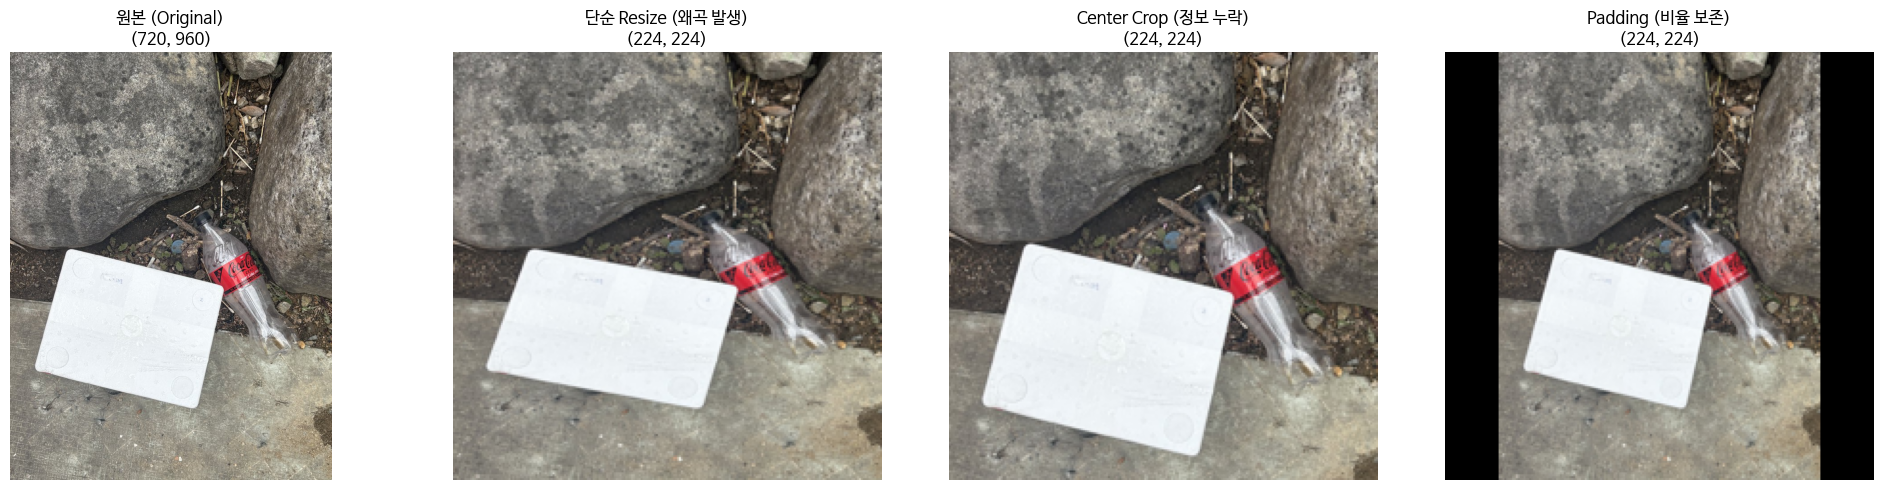

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np

def compare_preprocessing(img_path, target_size=(224, 224)):
    img = Image.open(img_path)

    # 1. Simple Resize (강제 리사이징 - 찌그러짐)
    res_img = img.resize(target_size)

    # 2. Center Crop (중앙 자르기 - 정보 손실)
    # 짧은 쪽 기준으로 맞추고 넘치는 부분 제거
    w, h = img.size
    min_dim = min(w, h)
    left = (w - min_dim) / 2
    top = (h - min_dim) / 2
    crop_img = img.crop((left, top, left + min_dim, top + min_dim)).resize(target_size)

    # 3. Letterbox Padding (패딩 후 리사이징 - 비율 보존)
    # 비율을 유지하며 긴 쪽을 target_size에 맞추고 빈 공간을 검은색으로 채움
    pad_img = ImageOps.pad(img, target_size, color=(0, 0, 0))

    # 시각화
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    imgs = [img, res_img, crop_img, pad_img]
    titles = ['원본 (Original)', '단순 Resize (왜곡 발생)', 'Center Crop (정보 누락)', 'Padding (비율 보존)']

    for i, (ax, im, title) in enumerate(zip(axes, imgs, titles)):
        ax.imshow(im)
        ax.set_title(f"{title}\n{im.size}", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# 샘플 실행
compare_preprocessing(train_df.sample(1)['path'].iloc[0])

## 분포 맞춤 샘플링 실험
이후 두 셀은 질문 유형·재질 축을 이용해 train/dev를 test 분포 쪽으로 다시 샘플링해 보는 실험입니다.
실제 학습 데이터 재구성 후보를 만든 흔적이라 EDA 중에서도 실험 성격이 강합니다.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

train_df = pd.read_csv('train.csv')
dev_df = pd.read_csv('dev.csv')
test_df = pd.read_csv('test.csv')

def classify_question_type(question):
    q = str(question).lower()

    if any(word in q for word in ['몇 개', '개수', '얼마나', '몇개']):
        return 'count'
    elif any(word in q for word in ['재질', '무엇으로', '만들어진', '어떤 소재']):
        return 'material'
    elif any(word in q for word in ['색상', '무슨 색', '색깔', '어떤 색']):
        return 'color'
    elif any(word in q for word in ['분리수거', '재활용 분류', '분류 기호', '분리배출', '어떻게 배출']):
        return 'recycling_class'
    elif any(word in q for word in ['가장 많이', '가장 많은', '주로', '주된', '가장 큰 비중', '비율']):
        return 'dominant_or_majority'
    elif any(word in q for word in ['위치', '어디에', '왼쪽', '오른쪽', '위', '아래', '옆', '어느 쪽에']):
        return 'position'
    elif any(word in q for word in ['브랜드', '상표', '로고', '제품명']):
        return 'brand_or_product'
    elif any(word in q for word in ['맛']):
        return 'flavor'
    elif any(word in q for word in ['글자', '기호', '텍스트', '쓰여진', '적혀있는', '적힌', '마크']):
        return 'text_or_symbol'
    elif any(word in q for word in ['종류', '무엇인가요', '품목', '무엇입니까', '어떤']):
        return 'object_type'
    else:
        return 'other'

for df in [train_df, dev_df, test_df]:
    df['q_type'] = df['question'].apply(classify_question_type)

def assign_material_class(row):
    text = str(row['question']) + " " + str(row.get('answer', ''))
    target_keywords = ['스티로폼', '유리', '캔', '종이', '비닐', '플라스틱']
    for kw in target_keywords:
        if kw in text:
            return kw
    return '기타'

train_df['material_class'] = train_df.apply(assign_material_class, axis=1)

# ==========================================
# 1. Train 데이터 증강 (최대 증강 배수 제한 적용)
# ==========================================
print("========== [Train] 데이터 처리 ==========")
print(f"[Train] 증강 전 전체 데이터 개수: {len(train_df)}개")
print(f"[Train] 증강 전 고유 ID 개수: {train_df['id'].nunique()}개\n")

print("=== 증강 전 재질 클래스 분포 ===")
before_counts = train_df['material_class'].value_counts()
print(before_counts)

target_count = before_counts.max()
MAX_MULTIPLIER = 3.0

print(f"\n[설정] 최대 클래스 기준 목표 개수: {target_count}개")
print(f"[설정] 단, 과적합 방지를 위해 최대 증강 배수를 {MAX_MULTIPLIER}배로 제한합니다.\n")

print("=== 클래스별 증강 배수 (제한 적용) ===")
augmented_list = []

for m_class, count in before_counts.items():
    if m_class == '기타':
        augmented_list.append(train_df[train_df['material_class'] == m_class])
        continue

    max_allowed_count = int(count * MAX_MULTIPLIER)
    final_target = min(target_count, max_allowed_count)
    multiplier = final_target / count

    print(f"- {m_class}: 현재 {count}개 -> 목표 {final_target}개 (약 {multiplier:.2f}배 증강)")

    class_df = train_df[train_df['material_class'] == m_class]

    if count < final_target:
        oversampled = resample(
            class_df,
            replace=True,
            n_samples=final_target,
            random_state=42
        )
        augmented_list.append(oversampled)
    else:
        augmented_list.append(class_df)

train_balanced = pd.concat(augmented_list).reset_index(drop=True)

print(f"\n[Train] 증강 완료 후 전체 데이터 개수: {len(train_balanced)}개")
print(f"[Train] 증강 완료 후 고유 ID 개수: {train_balanced['id'].nunique()}개")

print("\n=== 증강 완료 후 재질 클래스 분포 ===")
print(train_balanced['material_class'].value_counts())

# ==========================================
# 2. Valid(Dev) 데이터 처리
# ==========================================
print("\n========== [Valid] 데이터 처리 ==========")
print(f"[Valid] 샘플링 전 전체 Dev 데이터 개수: {len(dev_df)}개")
print(f"[Valid] 샘플링 전 Dev 고유 ID 개수: {dev_df['id'].nunique()}개\n")

dev_responses = dev_df[['answer1', 'answer2', 'answer3', 'answer4', 'answer5']]
dev_df['pseudo_label'] = dev_responses.mode(axis=1)[0]
dev_df['agreement_rate'] = dev_responses.apply(lambda x: (x == dev_df.loc[x.name, 'pseudo_label']).sum() / 5.0, axis=1)

dev_high_agreement = dev_df[dev_df['agreement_rate'] >= 0.6].copy()

test_type_ratios = test_df['q_type'].value_counts(normalize=True)

dev_sampled_list = []
total_dev_samples = min(len(dev_high_agreement), 1000)

for q_type, ratio in test_type_ratios.items():
    n_samples = int(total_dev_samples * ratio)
    type_data = dev_high_agreement[dev_high_agreement['q_type'] == q_type]

    if len(type_data) > 0:
        sampled = resample(
            type_data,
            replace=len(type_data) < n_samples,
            n_samples=n_samples,
            random_state=42
        )
        dev_sampled_list.append(sampled)

dev_validation = pd.concat(dev_sampled_list).reset_index(drop=True)
dev_validation['weight'] = dev_validation['agreement_rate']

print(f"\n[Valid] Test 비율 반영 샘플링 후 전체 Valid 데이터 개수: {len(dev_validation)}개")
print(f"[Valid] Test 비율 반영 샘플링 후 고유 ID 개수: {dev_validation['id'].nunique()}개")

print("\n=== Valid 데이터 질문 유형(q_type) 분포 (Test 비율 반영) ===")
print(dev_validation['q_type'].value_counts(normalize=True) * 100)

dev_validation['material_class'] = dev_validation.apply(assign_material_class, axis=1)
print("\n=== Valid 데이터 재질 클래스(material_class) 분포 ===")
print(dev_validation['material_class'].value_counts())

========== [Train] 데이터 처리 ==========
[Train] 증강 전 전체 데이터 개수: 5073개
[Train] 증강 전 고유 ID 개수: 5073개

=== 증강 전 재질 클래스 분포 ===
material_class
기타      1866
플라스틱    1835
종이       650
캔        455
유리       160
비닐        75
스티로폼      32
Name: count, dtype: int64

[설정] 최대 클래스 기준 목표 개수: 1866개
[설정] 단, 과적합 방지를 위해 최대 증강 배수를 3.0배로 제한합니다.

=== 클래스별 증강 배수 (제한 적용) ===
- 플라스틱: 현재 1835개 -> 목표 1866개 (약 1.02배 증강)
- 종이: 현재 650개 -> 목표 1866개 (약 2.87배 증강)
- 캔: 현재 455개 -> 목표 1365개 (약 3.00배 증강)
- 유리: 현재 160개 -> 목표 480개 (약 3.00배 증강)
- 비닐: 현재 75개 -> 목표 225개 (약 3.00배 증강)
- 스티로폼: 현재 32개 -> 목표 96개 (약 3.00배 증강)

[Train] 증강 완료 후 전체 데이터 개수: 7764개
[Train] 증강 완료 후 고유 ID 개수: 4286개

=== 증강 완료 후 재질 클래스 분포 ===
material_class
기타      1866
플라스틱    1866
종이      1866
캔       1365
유리       480
비닐       225
스티로폼      96
Name: count, dtype: int64

========== [Valid] 데이터 처리 ==========
[Valid] 샘플링 전 전체 Dev 데이터 개수: 4413개
[Valid] 샘플링 전 Dev 고유 ID 개수: 4413개


[Valid] Test 비율 반영 샘플링 후 전체 Valid 데이터 개수: 894개
[Valid] Test 비율 반영 샘플링 후 고유 ID 개수: 4

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

# 데이터 로드 (실제 환경에 맞게 경로 수정 필요)
train_df = pd.read_csv('train.csv')
dev_df = pd.read_csv('dev.csv')
test_df = pd.read_csv('test.csv')

def classify_question_type(question):
    q = str(question).lower()
    if any(word in q for word in ['몇 개', '개수', '얼마나', '몇개']): return 'count'
    elif any(word in q for word in ['재질', '무엇으로', '만들어진', '어떤 소재']): return 'material'
    elif any(word in q for word in ['색상', '무슨 색', '색깔', '어떤 색']): return 'color'
    elif any(word in q for word in ['분리수거', '재활용 분류', '분류 기호', '분리배출', '어떻게 배출']): return 'recycling_class'
    elif any(word in q for word in ['가장 많이', '가장 많은', '주로', '주된', '가장 큰 비중', '비율']): return 'dominant_or_majority'
    elif any(word in q for word in ['위치', '어디에', '왼쪽', '오른쪽', '위', '아래', '옆', '어느 쪽에']): return 'position'
    elif any(word in q for word in ['브랜드', '상표', '로고', '제품명']): return 'brand_or_product'
    elif any(word in q for word in ['맛']): return 'flavor'
    elif any(word in q for word in ['글자', '기호', '텍스트', '쓰여진', '적혀있는', '적힌', '마크']): return 'text_or_symbol'
    elif any(word in q for word in ['종류', '무엇인가요', '품목', '무엇입니까', '어떤']): return 'object_type'
    else: return 'other'

for df in [train_df, dev_df, test_df]:
    df['q_type'] = df['question'].apply(classify_question_type)

def assign_material_class(row):
    text = str(row['question']) + " " + str(row.get('answer', ''))
    target_keywords = ['스티로폼', '유리', '캔', '종이', '비닐', '플라스틱']
    for kw in target_keywords:
        if kw in text: return kw
    return '기타'

train_df['material_class'] = train_df.apply(assign_material_class, axis=1)

# ==========================================
# 1. Train 데이터 증강 (원본 100% 보존 로직 적용)
# ==========================================
print("========== [Train] 데이터 처리 ==========")
print(f"[Train] 증강 전 전체 데이터 개수: {len(train_df)}개")
print(f"[Train] 증강 전 고유 ID 개수: {train_df['id'].nunique()}개\n")

before_counts = train_df['material_class'].value_counts()
target_count = before_counts.max()
MAX_MULTIPLIER = 3.0

augmented_list = []

for m_class, count in before_counts.items():
    class_df = train_df[train_df['material_class'] == m_class]

    # [핵심 수정]: 원본 데이터는 무조건 100% 보존하여 리스트에 삽입
    augmented_list.append(class_df)

    if m_class == '기타':
        continue

    # 최대 허용 개수 및 추가로 더 필요한 개수(shortfall) 계산
    max_allowed_count = int(count * MAX_MULTIPLIER)
    final_target = min(target_count, max_allowed_count)
    shortfall = final_target - count

    if shortfall > 0:
        # 부족한 개수만큼만 복원 추출하여 추가
        oversampled = resample(
            class_df,
            replace=True,
            n_samples=shortfall,
            random_state=42
        )
        augmented_list.append(oversampled)

train_balanced = pd.concat(augmented_list).reset_index(drop=True)

print("=== 클래스별 증강 내역 ===")
for m_class, count in before_counts.items():
    final_count = len(train_balanced[train_balanced['material_class'] == m_class])
    print(f"- {m_class}: 원본 {count}개 -> 최종 {final_count}개")

print(f"\n[Train] 증강 완료 후 전체 데이터 개수: {len(train_balanced)}개")
print(f"[Train] 증강 완료 후 고유 ID 개수: {train_balanced['id'].nunique()}개 (원본과 정확히 일치해야 함)")


# ==========================================
# 2. Valid(Dev) 데이터 처리 (추적 로그 강화)
# ==========================================
print("\n========== [Valid] 데이터 처리 ==========")
print(f"[Valid] 초기 Dev 전체 데이터 개수: {len(dev_df)}개")
print(f"[Valid] 초기 Dev 고유 ID 개수: {dev_df['id'].nunique()}개\n")

dev_responses = dev_df[['answer1', 'answer2', 'answer3', 'answer4', 'answer5']]
dev_df['pseudo_label'] = dev_responses.mode(axis=1)[0]
dev_df['agreement_rate'] = dev_responses.apply(lambda x: (x == dev_df.loc[x.name, 'pseudo_label']).sum() / 5.0, axis=1)

dev_high_agreement = dev_df[dev_df['agreement_rate'] >= 0.8].copy()
print(f"[Valid 추적 1] 일치율 80% 이상 필터링 후 남은 데이터 개수: {len(dev_high_agreement)}개 (노이즈 제거로 인한 감소)")

test_type_ratios = test_df['q_type'].value_counts(normalize=True)

# 1000개 임의 제한을 풀고, 일치율 통과 데이터의 절반 수준을 목표치로 삼아 여유롭게 샘플링
total_dev_samples = int(len(dev_high_agreement) * 0.8)

dev_sampled_list = []

for q_type, ratio in test_type_ratios.items():
    n_samples = int(total_dev_samples * ratio)
    type_data = dev_high_agreement[dev_high_agreement['q_type'] == q_type]

    if len(type_data) > 0:
        # 다운샘플링일 경우 원본 유실 발생(분포를 맞추기 위한 수학적 필연), 오버샘플링일 경우 복원추출
        sampled = resample(
            type_data,
            replace=len(type_data) < n_samples,
            n_samples=n_samples,
            random_state=42
        )
        dev_sampled_list.append(sampled)

dev_validation = pd.concat(dev_sampled_list).reset_index(drop=True)
dev_validation['weight'] = dev_validation['agreement_rate']

print(f"\n[Valid 추적 2] Test 비율 반영 샘플링 완료 후 전체 Valid 데이터 개수: {len(dev_validation)}개")
print(f"[Valid 추적 2] Test 비율 반영 샘플링 완료 후 고유 ID 개수: {dev_validation['id'].nunique()}개")
print("*(참고: Test 분포를 억지로 맞추기 위해 특정 유형을 다운샘플링하면서 고유 ID가 감소하는 것은 정상적인 동작입니다)*\n")

print("=== Valid 데이터 질문 유형(q_type) 분포 (Test 비율 반영) ===")
print(dev_validation['q_type'].value_counts(normalize=True) * 100)

========== [Train] 데이터 처리 ==========
[Train] 증강 전 전체 데이터 개수: 5073개
[Train] 증강 전 고유 ID 개수: 5073개

=== 클래스별 증강 내역 ===
- 기타: 원본 1866개 -> 최종 1866개
- 플라스틱: 원본 1835개 -> 최종 1866개
- 종이: 원본 650개 -> 최종 1866개
- 캔: 원본 455개 -> 최종 1365개
- 유리: 원본 160개 -> 최종 480개
- 비닐: 원본 75개 -> 최종 225개
- 스티로폼: 원본 32개 -> 최종 96개

[Train] 증강 완료 후 전체 데이터 개수: 7764개
[Train] 증강 완료 후 고유 ID 개수: 5073개 (원본과 정확히 일치해야 함)

========== [Valid] 데이터 처리 ==========
[Valid] 초기 Dev 전체 데이터 개수: 4413개
[Valid] 초기 Dev 고유 ID 개수: 4413개

[Valid 추적 1] 일치율 80% 이상 필터링 후 남은 데이터 개수: 902개 (노이즈 제거로 인한 감소)

[Valid 추적 2] Test 비율 반영 샘플링 완료 후 전체 Valid 데이터 개수: 713개
[Valid 추적 2] Test 비율 반영 샘플링 완료 후 고유 ID 개수: 416개
*(참고: Test 분포를 억지로 맞추기 위해 특정 유형을 다운샘플링하면서 고유 ID가 감소하는 것은 정상적인 동작입니다)*

=== Valid 데이터 질문 유형(q_type) 분포 (Test 비율 반영) ===
q_type
count                   34.081346
material                30.715288
object_type             17.251052
color                    6.451613
recycling_class          4.067321
position                 4.067321
dominant_or_majority  

## 증강 시각화
마지막 셀은 Albumentations 기반 증강 결과를 이미지로 비교합니다.
어떤 변환이 객체 식별에 무리가 없는지 감으로 확인하는 용도입니다.

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_15866/220506918.py:19: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, min_holes=1,


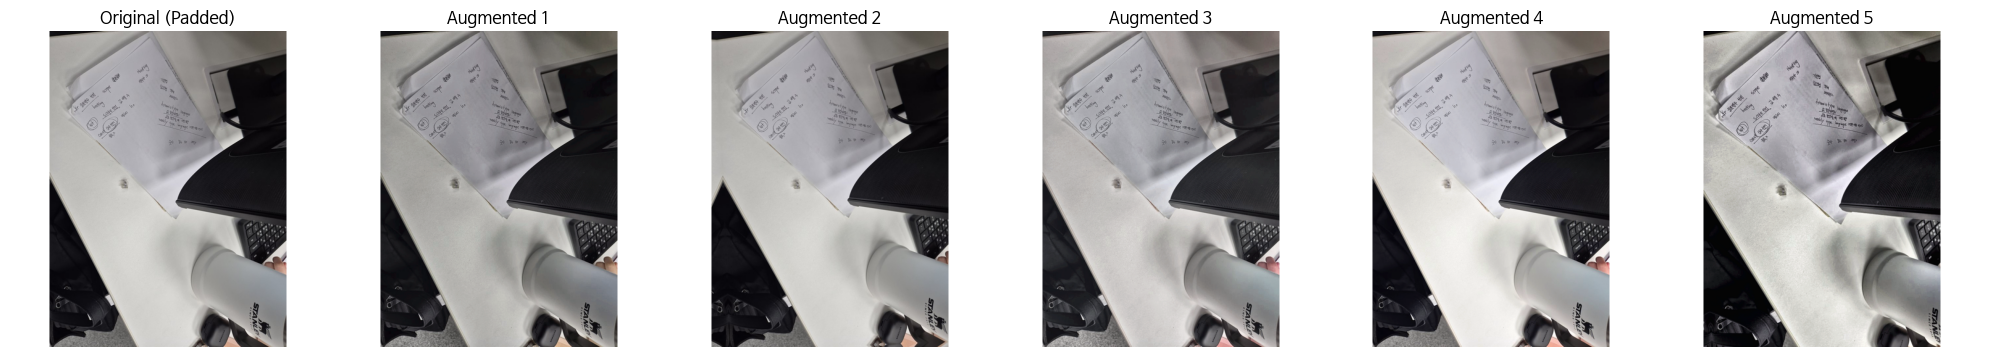

In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
from PIL import Image

# 1. 논리가 교정된 증강 파이프라인
augmentation = A.Compose([
    # HorizontalFlip 제거 (글자/로고 반전 방지)

    # 순백색 패딩 대신 원본 경계의 픽셀을 반사(Reflect)하여 자연스럽게 채움
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.8),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.6),
    A.CLAHE(clip_limit=2.5, tile_grid_size=(8, 8), p=0.5),

    # 컷아웃(Cutout) 방식의 노이즈 추가 - 모델이 특정 부분에만 의존하지 않게 만듦
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, min_holes=1,
                    fill_value=0, p=0.3)
])

def resize_with_padding(img, target_size=512):
    img_copy = img.copy()
    img_copy.thumbnail((target_size, target_size), Image.LANCZOS)
    padded = Image.new("RGB", (target_size, target_size), (255, 255, 255))
    offset = ((target_size - img_copy.width) // 2, (target_size - img_copy.height) // 2)
    padded.paste(img_copy, offset)
    return padded

def visualize_augmentations(image_path, num_samples=5):
    if not os.path.exists(image_path):
        print(f"이미지를 찾을 수 없습니다: {image_path}")
        return

    original_img = Image.open(image_path).convert("RGB")
    np_original = np.array(original_img)

    # 원본 이미지를 패딩 처리한 결과
    original_padded = resize_with_padding(original_img)

    fig, axes = plt.subplots(1, num_samples + 1, figsize=(20, 5))

    axes[0].imshow(original_padded)
    axes[0].set_title("Original (Padded)")
    axes[0].axis('off')

    for i in range(1, num_samples + 1):
        augmented = augmentation(image=np_original)["image"]
        aug_img = Image.fromarray(augmented)
        aug_padded = resize_with_padding(aug_img)

        axes[i].imshow(aug_padded)
        axes[i].set_title(f"Augmented {i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 사용 예시 (실제 이미지 경로로 변경하여 실행하십시오)
visualize_augmentations('train/train_0001.jpg')